Aqui va todo de lo que estoy seguro de usar

In [1]:
from limpio import *
import numpy as np
from sklearn.preprocessing import RobustScaler
from keras.callbacks import EarlyStopping
import torch.nn as nn
import torch
import pandas as pd
from tradepy.features import create_targets, generate_features, data_quality_report
import pywt


ImportError: cannot import name 'create_targets' from 'tradepy.features' (E:\Futuro\MLAlgoTrading\TradingBots\tradepy\tradepy\features.py)

In [80]:
df = pd.read_csv('../Data/gc1min.txt')
df.columns = df.columns.str.lower()
df = df.rename(columns={
    'vol': 'volume'
})
df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d')
df['time'] = df['time'].astype(str).str.zfill(6)
df['time'] = pd.to_datetime(df['time'], format='%H%M%S').dt.time
df['datetime'] = pd.to_datetime(df['dtyyyymmdd'].astype(str) + ' ' + df['time'].astype(str))
df = df.sort_values('datetime')

In [82]:
df.datetime.dt.hour.value_counts()

datetime
16    201172
15    201153
17    201136
18    201119
19    201027
14    201011
10    200938
11    200819
9     200778
12    200775
13    200744
8     199554
4     199496
3     198896
5     198409
7     197454
20    197131
6     197020
21    195074
22    194388
2     191435
23    188113
1     183075
0      15139
Name: count, dtype: int64

In [83]:
df.datetime.dt.day_of_week.value_counts()

datetime
3    922196
2    921818
1    921317
0    902256
4    897969
5       300
Name: count, dtype: int64

In [110]:
def import_dataset_v2(asset='gc1', format='min'):
    file_path = f'../Data/{asset}{format}.txt'
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.lower()
    df = df.rename(columns={
        'vol': 'volume'
    })
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d')
    # Asegurar que time tenga 6 dígitos (HHMMSS) y convertir a tipo time
    df['time'] = df['time'].astype(str).str.zfill(6)
    df['time'] = pd.to_datetime(df['time'], format='%H%M%S').dt.time
    # Unir fecha y hora en una sola columna de tipo datetime
    df['datetime'] = pd.to_datetime(df['dtyyyymmdd'].astype(str) + ' ' + df['time'].astype(str))
    df = df.sort_values('datetime')
    if asset == 'gc1':
        df['datetime'] = df['datetime'] - pd.Timedelta(hours=3)
    else:
        df['datetime'] = df['datetime'] - pd.Timedelta(hours=2)
    print(f"Dataset '{asset}' imported with {len(df)} rows")
    specs = pd.read_json("../Data/futuros_specs.json")
    spec = specs[asset[:2].upper()]
    return df, spec

In [111]:
def clean_v2(df, asset='gc1', break_hour=21):
    df = df.copy()

    # 1. Días de la semana: Lunes a viernes y domingos. Elimino los sábados
    df = df[df['datetime'].dt.weekday != 5]

    # 2. Eliminar la hora del break dinámicamente.
    df = df[df['datetime'].dt.hour != break_hour]

    # 3. Filtrar ruido alrededor del break (15 min antes y 15 min después).
    # Calculamos la hora previa y la hora posterior teniendo en cuenta el ciclo de 24h.
    prev_hour = (break_hour - 1) % 24
    next_hour = (break_hour + 1) % 24
    
    # Máscara para 15 minutos antes del cierre (ej: 22:45 a 22:59)
    mask_noise_before = (df['datetime'].dt.hour == prev_hour) & (df['datetime'].dt.minute >= 45)
    
    # Máscara para 15 minutos después de la apertura (ej: 00:00 a 00:15 o 01:00 a 01:15)
    mask_noise_after = (df['datetime'].dt.hour == next_hour) & (df['datetime'].dt.minute <= 15)
    
    # Aplicamos el filtro para quitar ese ruido
    df = df[~(mask_noise_before | mask_noise_after)]

    # 4. Definir trading day continuo.
    df['trading_date'] = (df['datetime'] + pd.Timedelta(hours=2)).dt.date

    # 5. Eliminar duplicados y asegurar orden temporal continuo.
    df = df.drop_duplicates(subset=['datetime']).sort_values('datetime')
    df = df.reset_index(drop=True)

    print(f"Limpieza {asset} completada. Filas restantes: {len(df)}")
    return df

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388


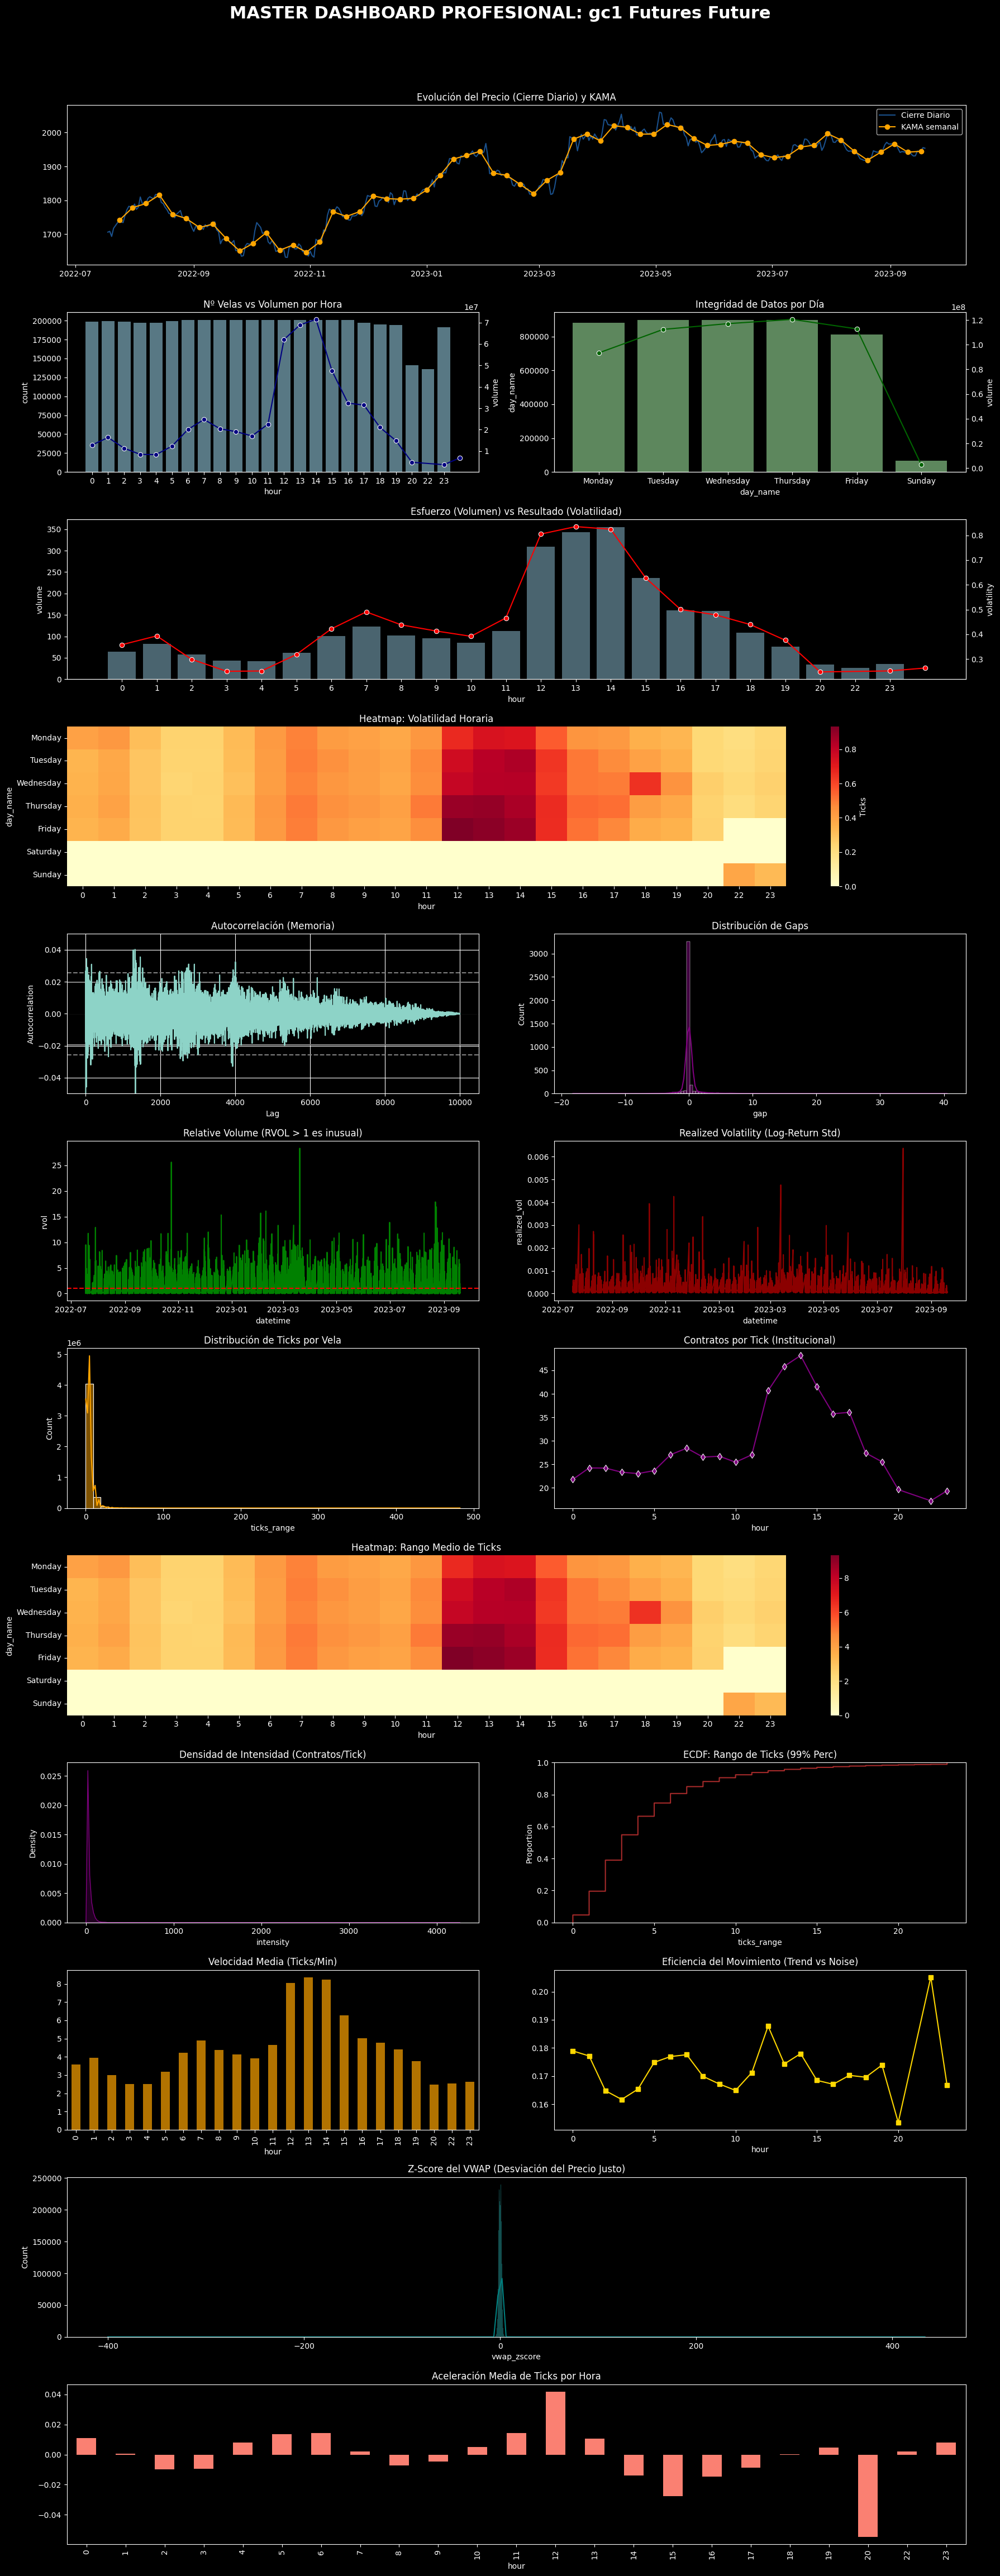

In [112]:
df_min_test, spec_test = import_dataset_v2(asset=ASSET)
df_min_clean_test = clean_v2(df_min_test, asset=ASSET)
# df_min_clean_test["close"] = wavelet_denoising(df_min_clean_test['close'].values.copy())
# df_resampled_test = get_multitimeframe_data(df_min_clean_test)
plot_master_market_analysis(df_min_clean_test, asset_name=f"{ASSET} Futures", tick_size=spec_test['tick_size'])

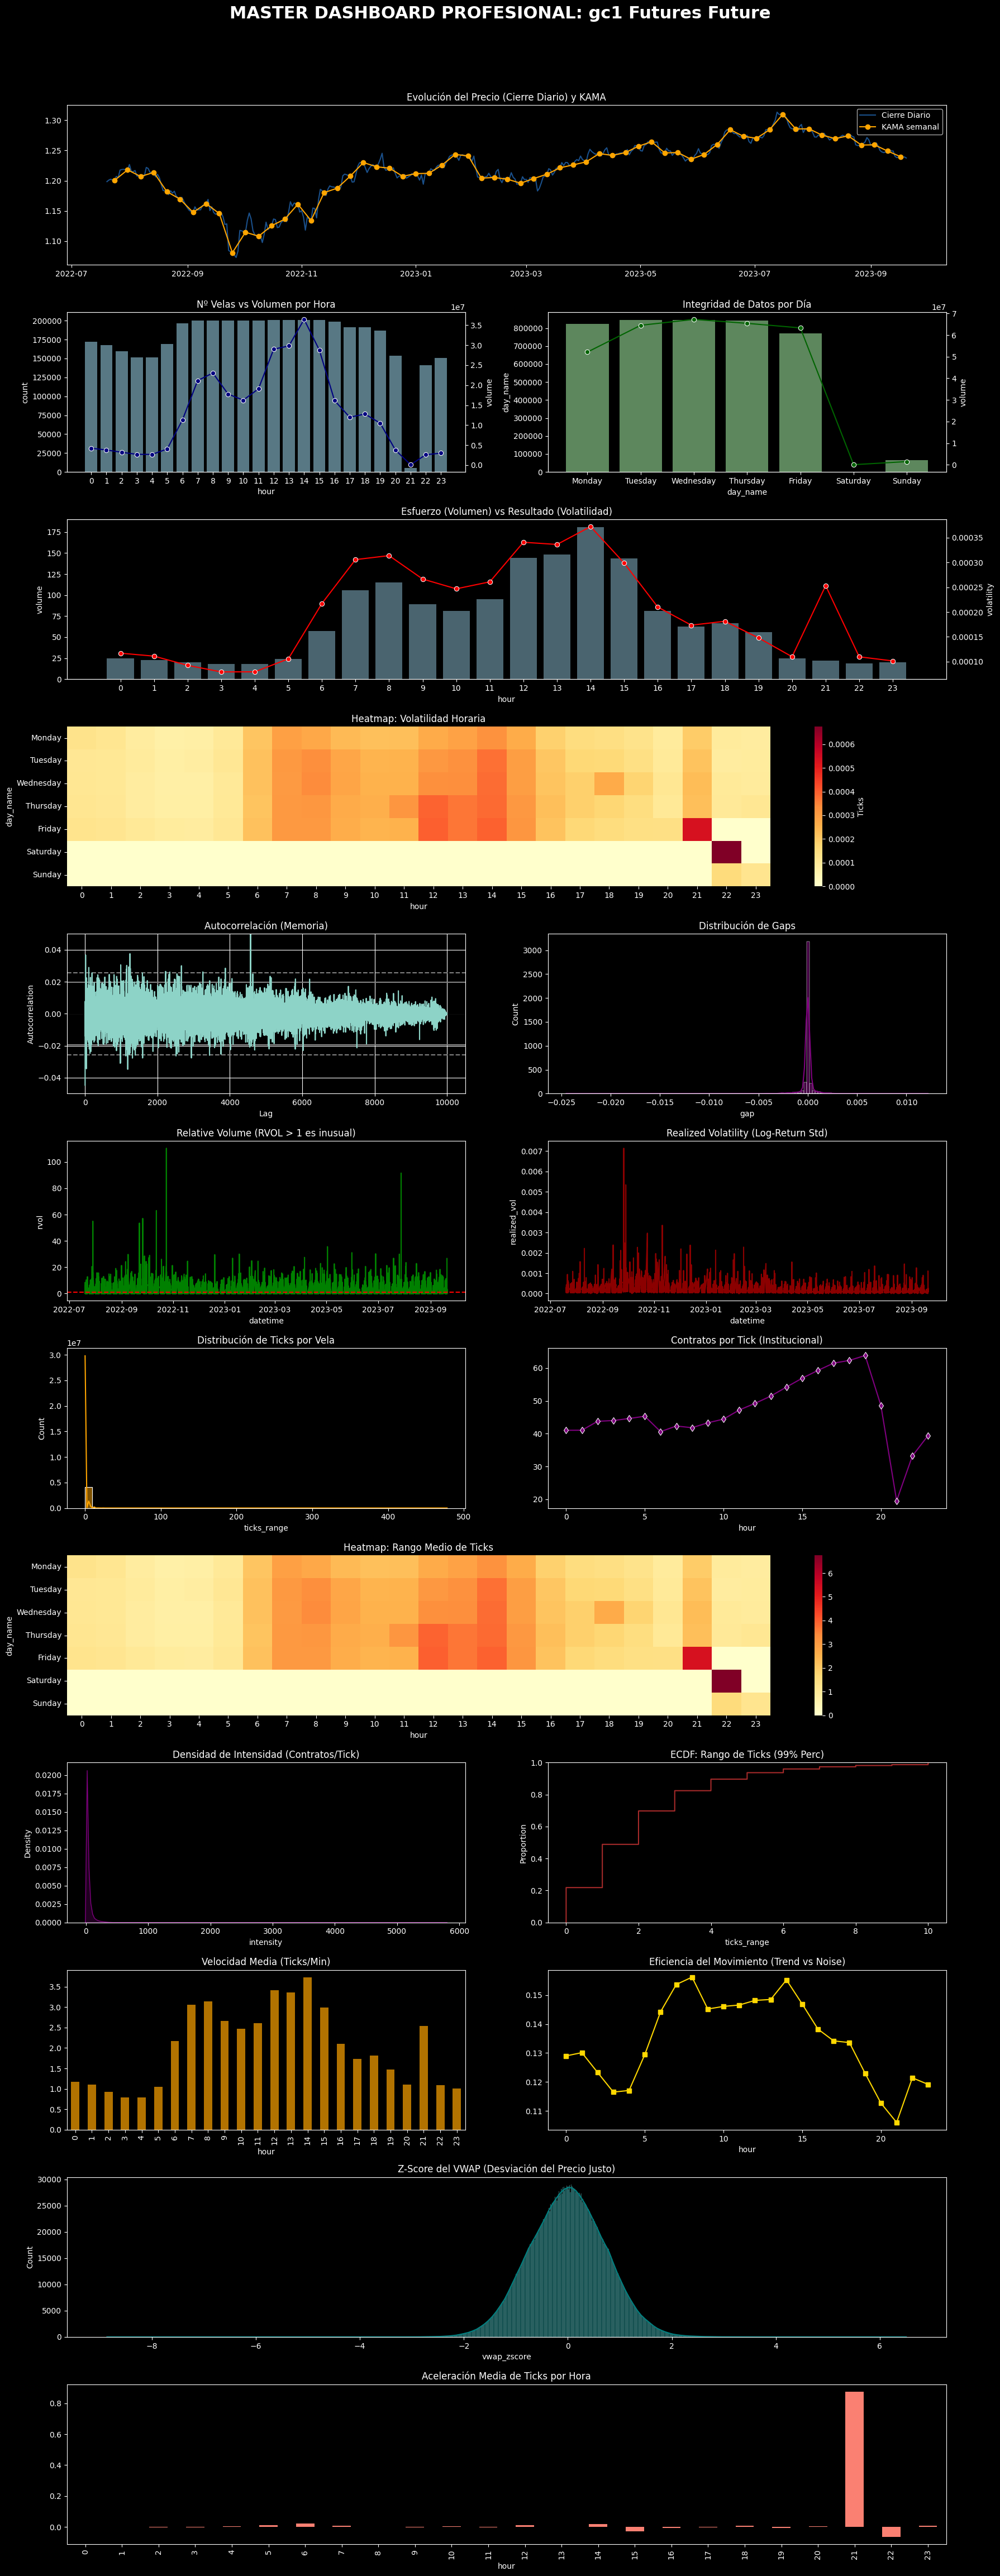

In [ ]:
plot_master_market_analysis(df_min_clean_test, asset_name=f"{ASSET} Futures", tick_size=spec_test['tick_size'])

In [2]:
asset_list = ["bp1", "cl1", "es1", "gc1"]
ASSET = asset_list[3]
MINUTES = 60
RETURN_HORIZON_MIN  = MINUTES * 2
torch.backends.cudnn.benchmark = True

In [3]:
# for asset in asset_list:
#     df_min, spec = import_dataset(asset=asset)
#     df_min_clean = clean(df_min, asset=asset, break_hour=spec['break_start'])
#     plot_master_market_analysis(df_min_clean, asset_name=f"{asset}", tick_size=spec['tick_size'], show=False, save=True)

In [4]:
def wavelet_denoising(x, wavelet='db4', level=1):
    # Descomponer la señal
    coeffs = pywt.wavedec(x, wavelet, mode='per')
    # Aplicar umbral para eliminar ruido (detalles de alta frecuencia)
    sigma = (1/0.6745) * np.median(np.abs(coeffs[-level] - np.median(coeffs[-level])))
    uthresh = sigma * np.sqrt(2 * np.log(len(x)))
    coeffs[1:] = [pywt.threshold(i, value=uthresh, mode='hard') for i in coeffs[1:]]
    # Reconstruir
    return pywt.waverec(coeffs, wavelet, mode='per')

In [5]:
df_min, spec = import_dataset(asset=ASSET)
df_min_clean = clean(df_min, asset=ASSET, break_hour=spec['break_start'])
df_min_clean["close"] = wavelet_denoising(df_min_clean['close'].values.copy())
df_resampled = get_multitimeframe_data(df_min_clean)
# plot_master_market_analysis(df_min_clean, asset_name=f"{ASSET} Futures", tick_size=spec['tick_size'])

Dataset 'gc1' imported with 4565856 rows
Limpieza gc1 completada. Filas restantes: 4456388
✅ Agregado: 5min | Filas: 901065
✅ Agregado: 15min | Filas: 300484
✅ Agregado: 30min | Filas: 153576
✅ Agregado: 60min | Filas: 76829


In [6]:
df_cumulative = apply_cumulative_stats_to_dict(df_resampled)

✅ Procesados acumulados diarios para: 5min
✅ Procesados acumulados diarios para: 15min
✅ Procesados acumulados diarios para: 30min
✅ Procesados acumulados diarios para: 60min


In [7]:
config = {
"global": {
"sampling_minutes": MINUTES,
"return_horizon_min": RETURN_HORIZON_MIN,
"tick_size": spec['tick_size']
},
"percent_return_features": {
"lags": [1,5,10,20],
"rolling_windows": [5,10,20]
},
"compute_atr": {"period": 14},
"obv": {
"roc_windows":[5,10],
"smooth_windows":[10],
"zscore_window":20,
"relative_volume_window":20,
"normalize_by":"range",
"include_manual": False,
"include_direction": True,
"include_delta": True
},
"ad": {
"zscore_window":20,
"roc_windows":[5,10],
"smooth_windows":[10],
"relative_volume_window":20,
"normalize_by":"range",
"include_clv": True,
"include_delta": True,
"include_direction": True
},
"rolling_slope": {"window":10, "source":"close"}
}

In [114]:
df_final = generate_features(df_cumulative[f'{MINUTES}min'], config_json=config, dropna_strategy='any')

In [9]:
report = data_quality_report(df_final, clean_infs=True, compute_corr=True, by_day=True)
print(report['column_profile'].sort_values('na_frac', ascending=False).head(30))

Data Quality Report
 - rows: 73437, cols: 144
 - top 20 NaN fractions:
datetime        0.0
open            0.0
high            0.0
low             0.0
close           0.0
volume          0.0
openint         0.0
dtyyyymmdd      0.0
ticker          0.0
per             0.0
trading_date    0.0
open_day        0.0
high_cum        0.0
low_cum         0.0
volume_cum      0.0
dist_to_high    0.0
dist_to_low     0.0
sma_20          0.0
ema_20          0.0
dema            0.0
dtype: float64
 - top corr with future: {'vpt': -0.02366713903005583, 'hour_cos': -0.01976680703240446, 'efi': -0.017778700677868717, 'ad_z': -0.01494703880438361, 'clv': -0.014799241621181982, 'close_location': -0.014799241556848662, 'ad_delta': -0.014053305179031148, 'bb_percent_b': -0.013603000235416393, 'cci': -0.012513157435633224, 'body_ticks': -0.012258020417762291, 'mfi': -0.012132451588802422, 'williams_r': -0.01199107920674621, 'dayofweek': -0.011600410625947234, 'slowd': -0.010992020712417517, 'slowk': -0.0109635

In [10]:
df_final_bin = create_targets(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], pos_threshold=0.0)

In [11]:
df_final_triple = create_targets(df_final, return_horizon_min=RETURN_HORIZON_MIN, sampling_minutes=MINUTES, tick_size=spec['tick_size'], pos_threshold=0.000718 , ternary=True)

In [12]:
EXCLUDE_COLS_TRIPLE = [
    # Identificadores / metadata
    'datetime', 'dtyyyymmdd', 'ticker', 'per', 'trading_date',

    # Constantes por resampling
    # 'openint', 'minute', 'minute_sin', 'minute_cos',

    # Targets
    f'target_logret_{RETURN_HORIZON_MIN}m', f'target_ret_{RETURN_HORIZON_MIN}m', f'target_ticks_{RETURN_HORIZON_MIN}m',
    'target_bin', 'target_class',

    # Booleanos opcionales
    'is_month_end', 'is_doji'
]

FEATURE_COLS_TRIPLE = [col for col in df_final_triple.columns if col not in EXCLUDE_COLS_TRIPLE]

EXCLUDE_COLS_BIN = [
    # Identificadores / metadata
    'datetime', 'dtyyyymmdd', 'ticker', 'per', 'trading_date',

    # Constantes por resampling
    # 'openint', 'minute', 'minute_sin', 'minute_cos',

    # Targets
    f'target_logret_{RETURN_HORIZON_MIN}m', f'target_ret_{RETURN_HORIZON_MIN}m', f'target_ticks_{RETURN_HORIZON_MIN}m',
    'target_bin',

    # Booleanos opcionales
    'is_month_end', 'is_doji'
]

FEATURE_COLS_BIN = [col for col in df_final_bin.columns if col not in EXCLUDE_COLS_BIN]

In [13]:
df_final_bin = audit_single_df(df_final_bin, FEATURE_COLS_BIN + ['target_bin'])
df_final_triple = audit_single_df(df_final_triple, FEATURE_COLS_TRIPLE + ['target_class'])

💎 Sin NaNs en features
💎 Sin NaNs en features


In [14]:
# df_final_dict = process_full_dictionary(df_cumulative, spec)

In [15]:
# df_final_dict[f'{MINUTES}min'].iloc[0].to_dict()

In [16]:
TARGET_COLUMN_BIN = 'target_bin' # 1 si sube, 0 si baja/lateral
TARGET_COLUMN_TRIPLE = 'target_class' # 2 si sube, 1 si lateral, 0 si baja

In [17]:
# df_final_dict = audit_and_clean_dict(df_final_dict, FEATURE_COLUMNS)

In [18]:
class GoldAttentionGRU_bin(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout, bidirectional=True)
        
        # Atención simple: calculamos pesos para cada paso temporal
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        self.fc = nn.Linear(hidden_dim * 2, 64)
        self.out = nn.Linear(64, output_dim)
        self.relu = nn.LeakyReLU(0.1)

    def forward(self, x):
        # gru_out: [batch, seq_len, hidden_dim * 2]
        gru_out, _ = self.gru(x)
        
        # Calcular pesos de atención
        weights = torch.softmax(self.attention(gru_out), dim=1)
        # Contexto: suma ponderada de los estados ocultos
        context = torch.sum(weights * gru_out, dim=1)
        
        out = self.bn(context)
        out = self.relu(self.fc(out))
        return self.out(out)
class GoldAttentionGRU_Triple(nn.Module):
    def __init__(self, input_dim, output_dim=3, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        # Usamos Bidirectional para que el modelo vea la estructura de la serie temporal en ambos sentidos
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, 
                          batch_first=True, dropout=dropout, bidirectional=True)
        
        # Mecanismo de Atención: mapea el estado oculto a una puntuación de importancia
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1)
        )
        
        # Normalización post-atención para estabilizar el entrenamiento triple
        self.bn = nn.BatchNorm1d(hidden_dim * 2)
        
        # Capas densas para clasificar en 3 categorías
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(64, output_dim) # output_dim = 3
        )

    def forward(self, x):
        # 1. Pasar por GRU: out shape [batch, seq_len, hidden_dim * 2]
        gru_out, _ = self.gru(x)
        
        # 2. Calcular pesos de atención para cada paso de la secuencia
        # energy shape: [batch, seq_len, 1]
        energy = self.attention(gru_out)
        weights = torch.softmax(energy, dim=1)
        
        # 3. Vector de contexto (Suma ponderada de todos los estados temporales)
        # context shape: [batch, hidden_dim * 2]
        context = torch.sum(weights * gru_out, dim=1)
        
        # 4. Clasificación final
        out = self.bn(context)
        logits = self.fc(out)
        
        return logits # Retorna logits (CrossEntropyLoss se encarga del Softmax internamente)

In [19]:
# result_bin, model_bin, sc_bin = run_gold_master_workflow(df_final_bin, FEATURE_COLS_BIN, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_BIN, train_size=20000, test_size=1000, step=500, lookback=48)
result_bin, model_bin, sc_bin = run_gold_master_workflow(df_final_bin, FEATURE_COLS_BIN, suffix=RETURN_HORIZON_MIN, model_class=GoldAttentionGRU_bin, target_col=TARGET_COLUMN_BIN, train_size=20000, test_size=1000, step=500, lookback=48, batch_size=1024)

Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

In [20]:
# result_triple, model_triple, sc_triple = run_gold_master_workflow(df_final_triple, FEATURE_COLS_TRIPLE, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48)
result_triple, model_triple, sc_triple = run_gold_master_workflow(df_final_triple, FEATURE_COLS_TRIPLE, suffix=RETURN_HORIZON_MIN, model_class=GoldAttentionGRU_Triple, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48, batch_size=2048)

Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

In [21]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_gold_performance(full_results):
    """
    Analiza estadísticamente los resultados del Walk-Forward.
    """
    y_true = full_results['actual']
    y_pred = full_results['pred']
    
    # 1. Identificar etiquetas
    unique_labels = sorted(full_results['actual'].unique())
    if len(unique_labels) == 2:
        target_names = ['No Sube (0)', 'Sube (1)']
    else:
        target_names = ['Sell (0)', 'Neutral (1)', 'Buy (2)']

    # 2. Generar Reporte de Clasificación
    print("📊 --- REPORTE DE CLASIFICACIÓN ---")
    print(classification_report(y_true, y_pred, target_names=target_names))
    
    # 3. Matriz de Confusión
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=target_names, yticklabels=target_names)
    plt.xlabel('Predicción (Modelo)')
    plt.ylabel('Realidad (Mercado)')
    plt.title('Matriz de Confusión: ¿Dónde se equivoca el modelo?')
    plt.show()

    # 4. Análisis de "Edge" (Ventaja Estadística)
    # Calculamos el retorno promedio por cada tipo de predicción
    print("\n💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---")
    edge_analysis = full_results.groupby('pred')['ret_real'].mean()
    for label, avg_ret in edge_analysis.items():
        name = target_names[int(label)]
        print(f"Cuando el modelo predice {name}, el retorno promedio real es: {avg_ret:.6f}")
    
    return accuracy_score(y_true, y_pred)

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 No Sube (0)       0.51      0.51      0.51     49876
    Sube (1)       0.51      0.51      0.51     50084

    accuracy                           0.51     99960
   macro avg       0.51      0.51      0.51     99960
weighted avg       0.51      0.51      0.51     99960



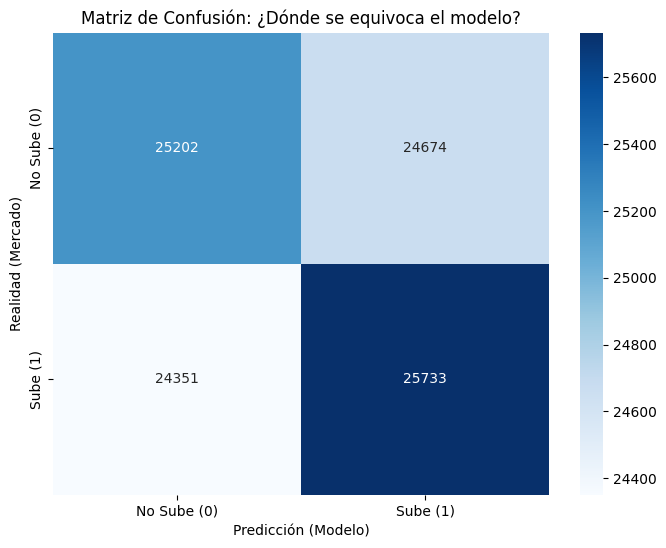


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice No Sube (0), el retorno promedio real es: -0.000002
Cuando el modelo predice Sube (1), el retorno promedio real es: 0.000042


0.5095538215286114

In [22]:
evaluate_gold_performance(result_bin)

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Sell (0)       0.39      0.10      0.16     32373
 Neutral (1)       0.37      0.88      0.52     34776
     Buy (2)       0.40      0.11      0.17     32811

    accuracy                           0.38     99960
   macro avg       0.39      0.36      0.28     99960
weighted avg       0.39      0.38      0.29     99960



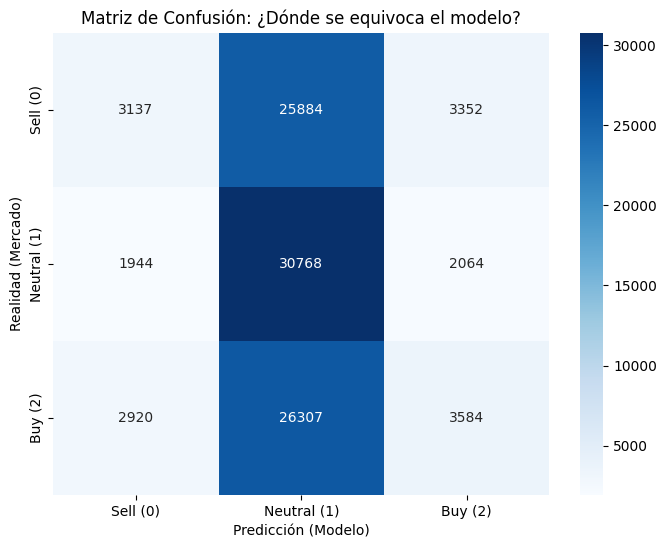


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice Sell (0), el retorno promedio real es: -0.000011
Cuando el modelo predice Neutral (1), el retorno promedio real es: 0.000025
Cuando el modelo predice Buy (2), el retorno promedio real es: 0.000009


0.3750400160064026

In [23]:
evaluate_gold_performance(result_triple)

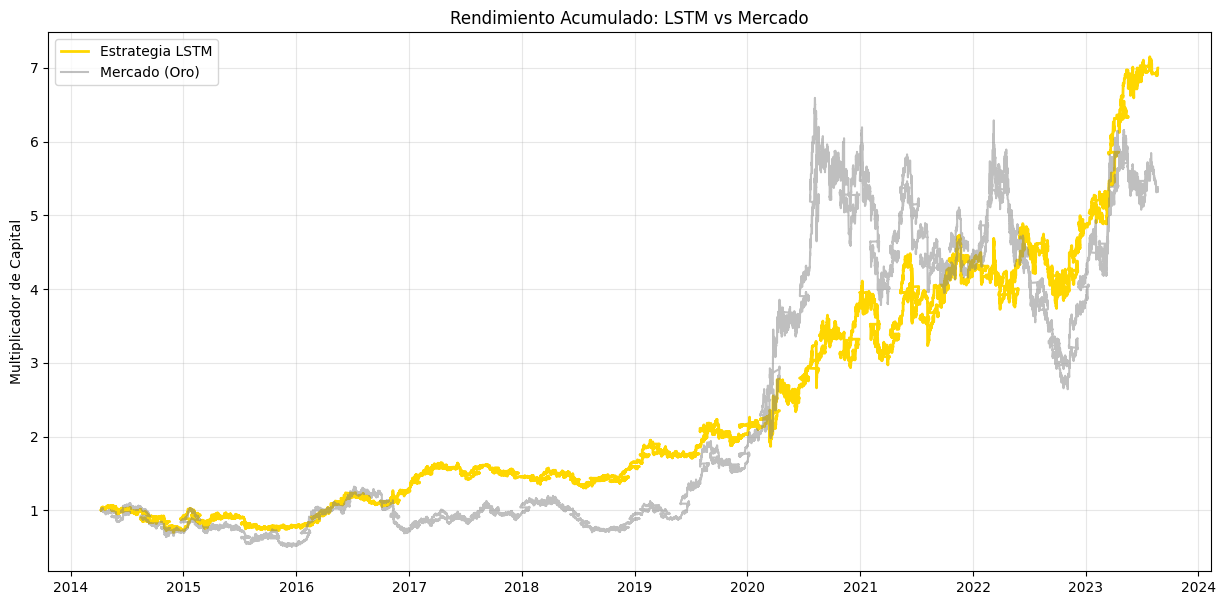

💰 Sharpe Ratio Estimado: 0.17
📈 Retorno Total Estrategia: 599.83%


In [24]:
plot_trading_results(result_bin)

In [25]:
import xgboost as xgb
import shap
def get_top_features_shap(df, target_col, feature_cols, top_n=25):

    # 1. Limpieza de NaNs
    df_clean = df[feature_cols + [target_col]].dropna()
    X = df_clean[feature_cols]
    y = df_clean[target_col]
    
    # 2. Entrenamiento rápido
    model = xgb.XGBClassifier(n_estimators=100, max_depth=4, tree_method='hist')
    model.fit(X, y)

    # 3. Cálculo de SHAP
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # --- BLOQUE DE CORRECCIÓN DE DIMENSIONES ---
    # SHAP multiclase devuelve (muestras, features, clases) o una lista de arrays
    if isinstance(shap_values, list):
        # Caso: Lista de arrays (uno por clase)
        abs_val = np.abs(np.array(shap_values)).mean(axis=0) # Promedio entre clases
        mean_shap = abs_val.mean(axis=0) # Promedio entre muestras
    elif len(shap_values.shape) == 3:
        # Caso: Array 3D (muestras, features, clases)
        mean_shap = np.abs(shap_values).mean(axis=(0, 2))
    else:
        # Caso: Binario (muestras, features)
        mean_shap = np.abs(shap_values).mean(axis=0)
    
    # Verificación de seguridad
    if len(mean_shap) != len(feature_cols):
        print(f"⚠️ Error de dimensión: SHAP {len(mean_shap)} vs Cols {len(feature_cols)}")
        # Forzar ajuste si algo sale mal (fallback)
        mean_shap = mean_shap[:len(feature_cols)]

    # 4. Crear DataFrame de resultados
    importance_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': mean_shap
    }).sort_values(by='importance', ascending=False)

    # 5. Top N y Gráfico
    top_features = importance_df.head(top_n)['feature'].tolist()
    
    plt.figure(figsize=(10, 8))
    # Usamos el resumen de barras nativo de SHAP para el top_n
    shap.summary_plot(shap_values, X, plot_type="bar", max_display=top_n, show=True)
    
    return top_features, importance_df

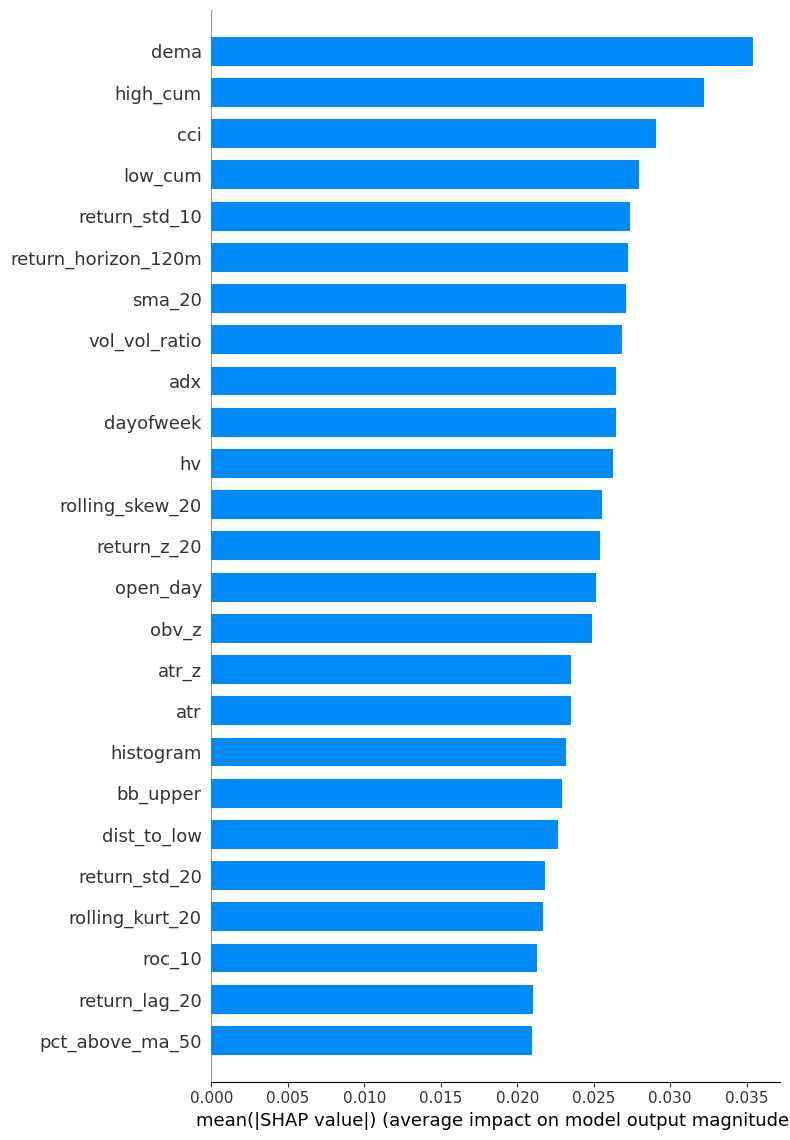

In [26]:
top_features_bin, importance_df_bin = get_top_features_shap(df_final_bin, TARGET_COLUMN_BIN, FEATURE_COLS_BIN, top_n=25)


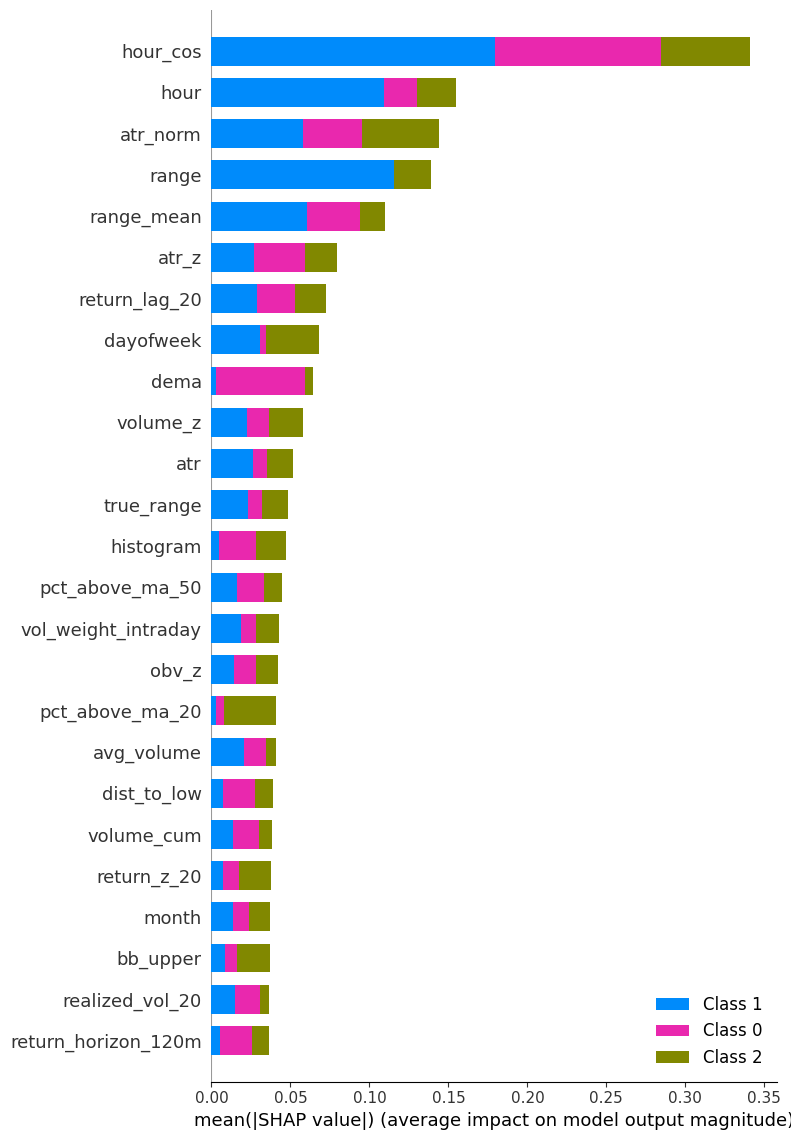

In [27]:
top_features_triple, importance_df_triple = get_top_features_shap(df_final_triple, TARGET_COLUMN_TRIPLE, FEATURE_COLS_TRIPLE, top_n=25)


In [28]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def reduce_by_vif(df, feature_list, threshold=10.0):
    """
    Calcula el VIF y elimina features una a una hasta que todas 
    estén por debajo del umbral (threshold).
    """
    # 1. Copiamos y limpiamos NaNs (VIF no acepta NaNs)
    X = df[feature_list].dropna().copy()
    # Añadimos una constante (requerido por statsmodels para el cálculo)
    X = add_constant(X)
    
    current_features = list(X.columns)
    
    while True:
        vif_data = pd.DataFrame()
        vif_data["feature"] = current_features
        vif_data["VIF"] = [variance_inflation_factor(X[current_features].values, i) 
                           for i in range(len(current_features))]
        
        # Ignoramos la constante para la eliminación
        vif_filtered = vif_data[vif_data["feature"] != "const"]
        max_vif = vif_filtered["VIF"].max()
        
        if max_vif > threshold:
            feature_to_remove = vif_filtered.sort_values("VIF", ascending=False).iloc[0]["feature"]
            print(f"🗑️ Eliminando '{feature_to_remove}' (VIF: {max_vif:.2f})")
            current_features.remove(feature_to_remove)
        else:
            break
            
    final_features = [f for f in current_features if f != "const"]
    print(f"✅ Proceso terminado. Quedan {len(final_features)} features independientes.")
    return final_features

# --- USO ---
# features_finales = reduce_by_vif(df_final, top_25_shap, threshold=10.0)

In [29]:
features_finales_bin =reduce_by_vif(df_final_bin, top_features_bin, threshold=10.0)

🗑️ Eliminando 'low_cum' (VIF: 107462.92)
🗑️ Eliminando 'hv' (VIF: 44027.39)
🗑️ Eliminando 'sma_20' (VIF: 39623.16)
🗑️ Eliminando 'high_cum' (VIF: 8301.45)
🗑️ Eliminando 'dema' (VIF: 6145.41)
🗑️ Eliminando 'bb_upper' (VIF: 2047.33)
✅ Proceso terminado. Quedan 19 features independientes.


In [30]:
final_features_triple = reduce_by_vif(df_final_triple, top_features_triple, threshold=10.0)

🗑️ Eliminando 'true_range' (VIF: 23807.51)
🗑️ Eliminando 'bb_upper' (VIF: 4182.74)
🗑️ Eliminando 'atr' (VIF: 61.33)
🗑️ Eliminando 'pct_above_ma_20' (VIF: 54.81)
🗑️ Eliminando 'range_mean' (VIF: 10.21)
✅ Proceso terminado. Quedan 20 features independientes.


In [31]:
# result_bin_second, model_bin_second, sc_bin_second = run_gold_master_workflow(df_final_bin, features_finales_bin, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_BIN, train_size=20000, test_size=1000, step=500, lookback=48)
result_bin_second, model_bin_second, sc_bin_second = run_gold_master_workflow(df_final_bin, features_finales_bin, suffix=RETURN_HORIZON_MIN, model_class=GoldAttentionGRU_bin, target_col=TARGET_COLUMN_BIN, train_size=20000, test_size=1000, step=500, lookback=48)

Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

 No Sube (0)       0.50      0.52      0.51     49876
    Sube (1)       0.51      0.49      0.50     50084

    accuracy                           0.51     99960
   macro avg       0.51      0.51      0.51     99960
weighted avg       0.51      0.51      0.51     99960



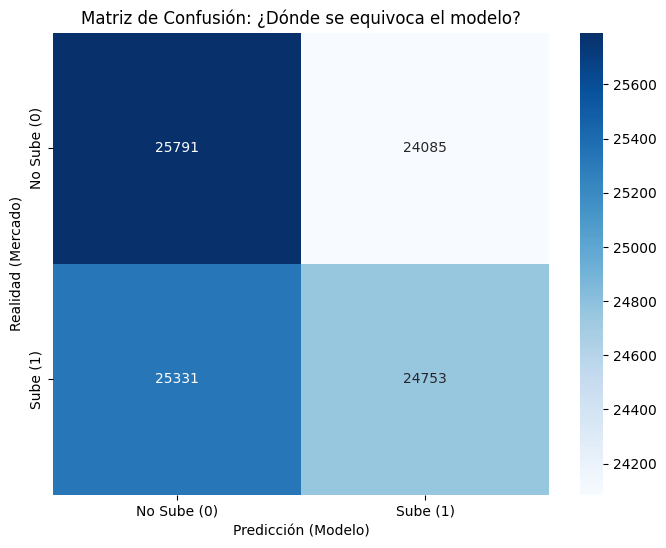


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice No Sube (0), el retorno promedio real es: 0.000016
Cuando el modelo predice Sube (1), el retorno promedio real es: 0.000025


0.5056422569027611

In [32]:
evaluate_gold_performance(result_bin_second)

In [33]:
# result_triple_second, model_triple_second, sc_triple_second = run_gold_master_workflow(df_final_triple, final_features_triple, suffix=RETURN_HORIZON_MIN, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48)
result_triple_second, model_triple_second, sc_triple_second = run_gold_master_workflow(df_final_triple, final_features_triple, suffix=RETURN_HORIZON_MIN, model_class=GoldAttentionGRU_Triple, target_col=TARGET_COLUMN_TRIPLE, train_size=20000, test_size=1000, step=500, lookback=48)

Gold Workflow:   0%|          | 0/105 [00:00<?, ?it/s]

📊 --- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

    Sell (0)       0.40      0.08      0.13     32373
 Neutral (1)       0.38      0.90      0.53     34776
     Buy (2)       0.42      0.14      0.21     32811

    accuracy                           0.39     99960
   macro avg       0.40      0.37      0.29     99960
weighted avg       0.40      0.39      0.30     99960



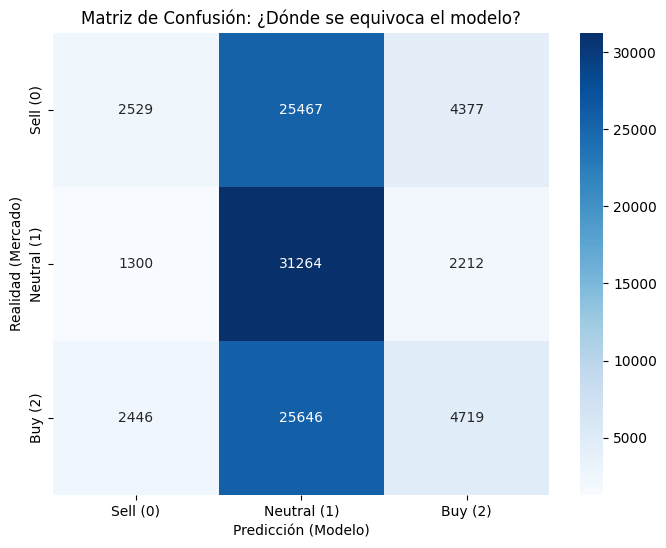


💰 --- ANÁLISIS DE RETORNO POR PREDICCIÓN ---
Cuando el modelo predice Sell (0), el retorno promedio real es: -0.000087
Cuando el modelo predice Neutral (1), el retorno promedio real es: 0.000019
Cuando el modelo predice Buy (2), el retorno promedio real es: 0.000092


0.38527410964385755

In [34]:
evaluate_gold_performance(result_triple_second)

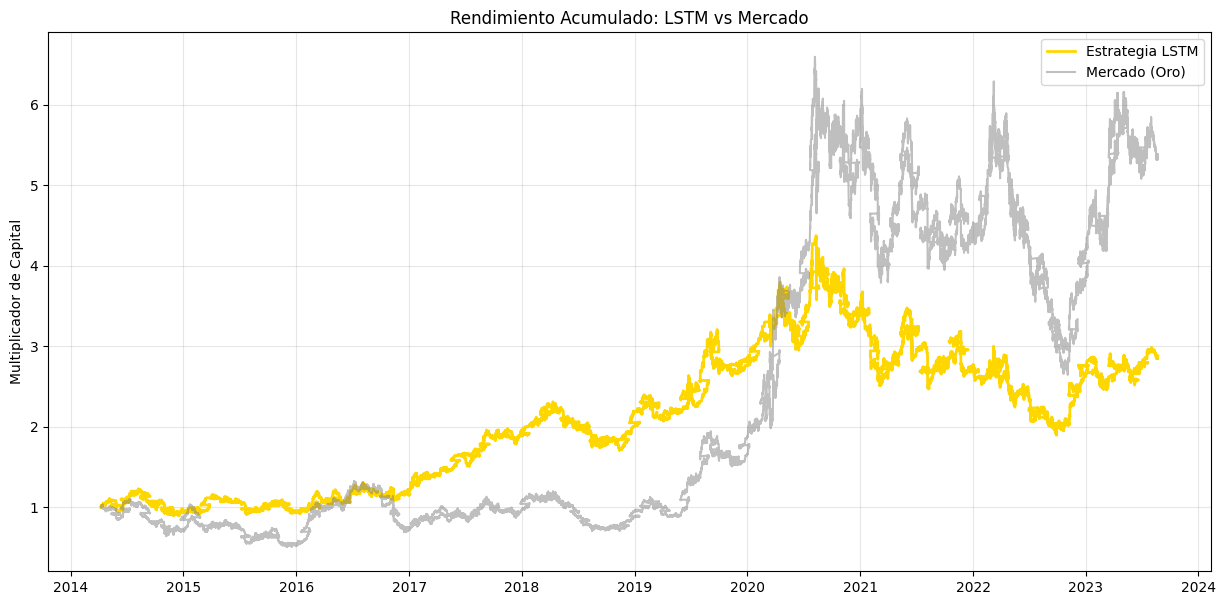

💰 Sharpe Ratio Estimado: 0.10
📈 Retorno Total Estrategia: 187.78%


In [35]:
plot_trading_results(result_bin_second)

In [36]:
def analyze_sharpe_by_threshold(df_res, thresholds=[0.5, 0.52, 0.55, 0.58, 0.6], mode='bin'):
    """
    Calcula el Sharpe Ratio para diferentes niveles de confianza del modelo.
    """
    results = []
    ann_factor = np.sqrt(252 * 48) # Ajustado a tus velas de 30/60 min
    
    for t in thresholds:
        df_t = df_res.copy()
        
        if mode == 'bin':
            # Solo compramos si prob_up > t
            df_t['signal'] = (df_t['prob_up'] > t).astype(int)
        else:
            # Ternario: Compra si prob_buy > t, Vende si prob_sell > t
            df_t['signal'] = 0
            df_t.loc[df_t['prob_2'] > t, 'signal'] = 1
            df_t.loc[df_t['prob_0'] > t, 'signal'] = -1
            
        df_t['strat_ret'] = df_t['signal'] * df_t['ret_real']
        
        # Métricas
        mu = df_t['strat_ret'].mean()
        sigma = df_t['strat_ret'].std()
        sharpe = (mu / sigma) * ann_factor if sigma > 0 else 0
        num_trades = (df_t['signal'] != 0).sum()
        
        results.append({'Umbral': t, 'Sharpe': sharpe, 'Trades': num_trades})
        print(f"Confianza > {t:.2f} | Sharpe: {sharpe:.4f} | Trades: {num_trades}")

    return pd.DataFrame(results)

# Uso:
# df_sharpe_test = analyze_sharpe_by_threshold(result_bin, mode='bin')

In [37]:
analyze_sharpe_by_threshold(result_triple_second, mode='triple')

Confianza > 0.50 | Sharpe: 0.3080 | Trades: 720
Confianza > 0.52 | Sharpe: 0.4641 | Trades: 468
Confianza > 0.55 | Sharpe: 0.0526 | Trades: 230
Confianza > 0.58 | Sharpe: 0.1154 | Trades: 114
Confianza > 0.60 | Sharpe: 0.2543 | Trades: 85


,Umbral,Sharpe,Trades
0,0.50,0.307983,720
1,0.52,0.464076,468
2,0.55,0.052584,230
3,0.58,0.115386,114
4,0.60,0.254330,85


In [48]:
analyze_sharpe_by_threshold(result_bin_second, mode='bin')

Confianza > 0.50 | Sharpe: 0.7197 | Trades: 48838
Confianza > 0.52 | Sharpe: 0.7419 | Trades: 41498
Confianza > 0.55 | Sharpe: 0.5091 | Trades: 31192
Confianza > 0.58 | Sharpe: 0.6119 | Trades: 22318
Confianza > 0.60 | Sharpe: 0.9051 | Trades: 17362


,Umbral,Sharpe,Trades
0,0.50,0.719740,48838
1,0.52,0.741891,41498
2,0.55,0.509129,31192
3,0.58,0.611910,22318
4,0.60,0.905084,17362


In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

class BacktestEngine:
    def __init__(self, df, mode='auto', tick_size=0.1, candles_per_day=48):
        """
        df: DataFrame que debe contener ['datetime', 'close', 'prob_0', 'prob_1', 'prob_2']
        mode: 'tri' (0,1,2) o 'bin' (up/down)
        tick_size: 0.1 para Oro (XAUUSD) típicamente.
        """
        self.df = df.copy()
        # Mapeo de nombres para asegurar compatibilidad
        rename_map = {'prob_sell': 'prob_0', 'prob_neutral': 'prob_1', 'prob_buy': 'prob_2', 'prob_up': 'prob_2'}
        self.df = self.df.rename(columns={k: v for k, v in rename_map.items() if k in self.df.columns})
        
        self.df['datetime'] = pd.to_datetime(self.df['datetime'])
        self.df = self.df.sort_values('datetime').reset_index(drop=True)
        self.tick_size = tick_size
        self.candles_per_day = candles_per_day
        
        if mode == 'auto':
            self.mode = 'tri' if 'prob_1' in self.df.columns else 'bin'
        else:
            self.mode = mode

    def run(self, 
            conf_threshold=0.58, 
            horizonte=2,          # Tus 2 velas de 60min (2 horas)
            only_long=True, 
            tp_ticks=None, 
            sl_ticks=None, 
            cost_ticks=1.5,       # Spread + Comisión en ticks
            slippage_prob=0.2,    # Probabilidad de sufrir deslizamiento
            slippage_ticks=1.0):  # Cuántos ticks perdemos en el deslizamiento
        
        df = self.df.copy()
        df['signal'] = 0
        returns = np.zeros(len(df))

        # 1. Generación de Señales
        if self.mode == 'tri':
            # Buy (2) es el máximo y supera el umbral
            buy_mask = (df['prob_2'] > df['prob_1']) & \
                       (df['prob_2'] > df['prob_0']) & \
                       (df['prob_2'] > conf_threshold)
            df.loc[buy_mask, 'signal'] = 1
            
            if not only_long:
                sell_mask = (df['prob_0'] > df['prob_1']) & \
                            (df['prob_0'] > df['prob_2']) & \
                            (df['prob_0'] > conf_threshold)
                df.loc[sell_mask, 'signal'] = -1
        else:
            df.loc[df['prob_2'] > conf_threshold, 'signal'] = 1

        # 2. Cálculo de Fricción
        # El coste se calcula como porcentaje del precio para aplicarlo al retorno
        cost_decimal = (cost_ticks * self.tick_size) / df['close']
        slippage_array = np.where(np.random.rand(len(df)) < slippage_prob, 
                                  (slippage_ticks * self.tick_size) / df['close'], 0)

        # 3. Bucle de Simulación de Trades
        # Iteramos hasta len - horizonte para no salirnos del array
        for i in range(len(df) - horizonte):
            sig = df['signal'].iloc[i]
            if sig == 0:
                continue
                
            price_entry = df['close'].iloc[i]
            friction = cost_decimal.iloc[i] + slippage_array[i]
            
            # Ventana de precios futuros para TP/SL
            future_prices = df['close'].iloc[i+1 : i+1+horizonte]
            
            trade_closed = False
            
            # Verificación de TP/SL dentro del horizonte
            if tp_ticks or sl_ticks:
                tp_val = (tp_ticks * self.tick_size) if tp_ticks else 9e10
                sl_val = (sl_ticks * self.tick_size) if sl_ticks else 9e10
                
                for t, price_current in enumerate(future_prices):
                    diff_usd = sig * (price_current - price_entry)
                    
                    if diff_usd <= -sl_val:
                        returns[i] = (-sl_val / price_entry) - friction
                        trade_closed = True
                        break
                    elif diff_usd >= tp_val:
                        returns[i] = (tp_val / price_entry) - friction
                        trade_closed = True
                        break
            
            # Si no ha tocado TP/SL, cierra al final del horizonte
            if not trade_closed:
                price_exit = future_prices.iloc[-1]
                raw_ret = sig * ((price_exit / price_entry) - 1)
                returns[i] = raw_ret - friction

        df['strat_ret'] = returns
        
        # 4. Métricas Finales
        df['cum_strat'] = (1 + df['strat_ret']).cumprod()
        
        # Sharpe Anualizado
        std = df['strat_ret'].std()
        ann_factor = np.sqrt(252 * self.candles_per_day)
        sharpe = (df['strat_ret'].mean() / std) * ann_factor if std > 0 else 0
        
        # Max Drawdown
        roll_max = df['cum_strat'].cummax()
        drawdown = (df['cum_strat'] - roll_max) / roll_max
        max_dd = drawdown.min()

        self._print_report(df, sharpe, max_dd)
        self._plot_results(df, sharpe)
        
        return df

    def _print_report(self, df, sharpe, max_dd):
        trades = df[df['signal'] != 0]
        pos_trades = df[df['strat_ret'] > 0]
        
        print("\n" + "="*45)
        print(f"📊 BACKTEST SNIPER [Modo: {self.mode.upper()}]")
        print("="*45)
        print(f"💰 Sharpe Ratio:     {sharpe:.4f}")
        print(f"📉 Max Drawdown:     {max_dd*100:.2f}%")
        print(f"📈 Retorno Total:    {(df['cum_strat'].iloc[-1]-1)*100:.2f}%")
        print(f"🎯 Win Rate:         {(len(pos_trades)/len(trades)*100 if len(trades)>0 else 0):.2f}%")
        print(f"⚖️ Total Trades:     {len(trades)}")
        print(f"📅 Periodo:          {df['datetime'].min().date()} al {df['datetime'].max().date()}")
        print("="*45)

    def _plot_results(self, df, sharpe):
        plt.style.use('dark_background') # Estilo más profesional
        plt.figure(figsize=(14, 6))
        plt.plot(df['datetime'], df['cum_strat'], label=f'Estrategia (Sharpe: {sharpe:.2f})', color='gold', lw=2)
        plt.title('Equity Curve - Gold Sniper Strategy', fontsize=14)
        plt.ylabel('Multiplicador de Capital')
        plt.grid(alpha=0.1)
        plt.legend()
        plt.tight_layout()
        plt.show()

# --- EJEMPLO DE USO ---
# bt = BacktestEngine(result_triple_second_with_close)
# res = bt.run(conf_threshold=0.58, horizonte=2, sl_ticks=40)

In [39]:
result_triple_second_with_close = pd.merge_asof(result_triple_second.copy().sort_values('datetime'), df_final_triple[['datetime', 'close']].copy().sort_values('datetime')
, on='datetime', direction='backward')

In [40]:
result_bin_second_with_close = pd.merge_asof(result_bin_second.copy().sort_values('datetime'), df_final_bin[['datetime', 'close']].copy().sort_values('datetime')
, on='datetime', direction='backward')

In [54]:
# bt_bin = BacktestEngine(result_bin_second, tick_size=spec['tick_size'], candles_per_day=25*60/MINUTES)
bt_triple = BacktestEngine(result_triple_second_with_close, tick_size=spec['tick_size'], candles_per_day=25*60/MINUTES)

In [43]:
bt_bin = BacktestEngine(result_bin_second_with_close, tick_size=spec['tick_size'], candles_per_day=25*60/MINUTES)


📊 BACKTEST SNIPER [Modo: BIN]
💰 Sharpe Ratio:     0.4428
📉 Max Drawdown:     -40.28%
📈 Retorno Total:    46.71%
🎯 Win Rate:         46.12%
⚖️ Total Trades:     17362
📅 Periodo:          2014-04-08 al 2023-08-22


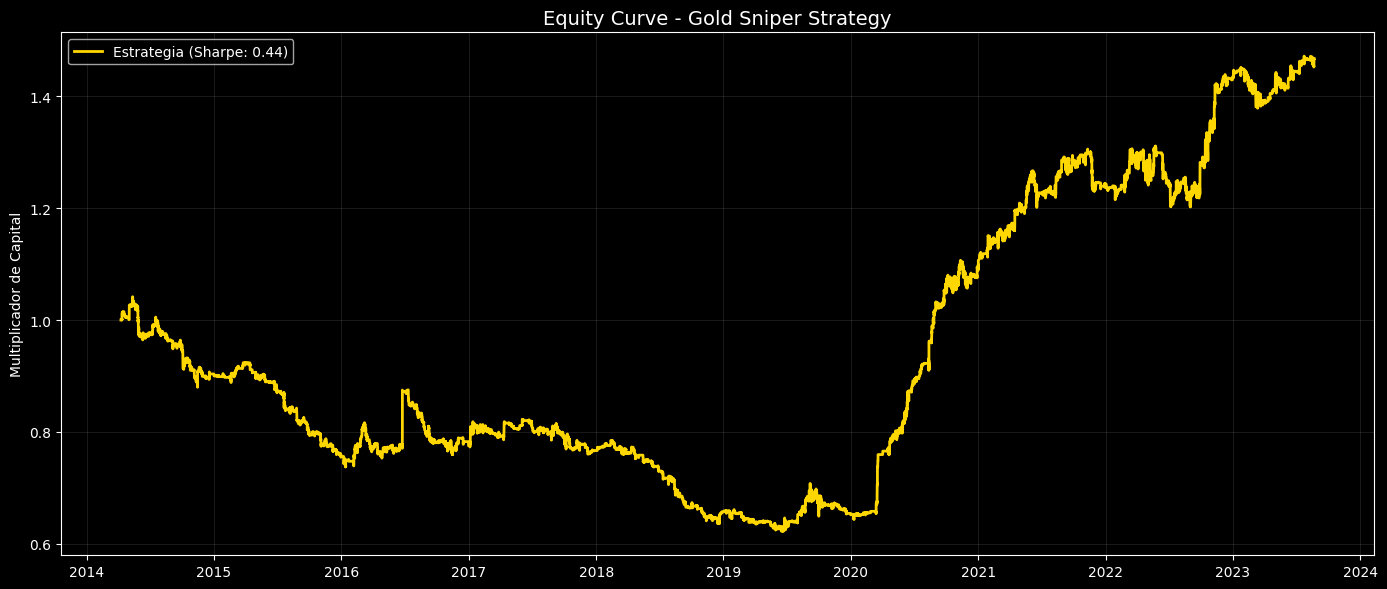

,datetime,actual,pred,prob_2,ret_real,strat_ret,cum_strat,cum_market,close,signal
0,2014-04-08 23:00:00,1,1,0.588456,0.000632,0.0,1.000000,1.000632,1309.143448,0
1,2014-04-09 02:00:00,1,1,0.590925,0.000386,0.0,1.000000,1.001018,1309.347573,0
2,2014-04-09 03:00:00,1,1,0.592909,0.002578,0.0,1.000000,1.003599,1309.970630,0
3,2014-04-09 04:00:00,1,1,0.572242,0.002035,0.0,1.000000,1.005641,1309.853073,0
4,2014-04-09 05:00:00,0,1,0.554780,-0.000792,0.0,1.000000,1.004845,1313.347827,0
...,...,...,...,...,...,...,...,...,...,...
99955,2023-08-22 04:00:00,1,1,0.581597,0.000507,0.0,1.467055,5.357252,1923.760959,0
99956,2023-08-22 05:00:00,1,1,0.572973,0.000034,0.0,1.467055,5.357433,1923.165122,0
99957,2023-08-22 06:00:00,0,1,0.569314,-0.000327,0.0,1.467055,5.355683,1924.736169,0
99958,2023-08-22 07:00:00,1,1,0.563545,0.002002,0.0,1.467055,5.366405,1923.230091,0


In [49]:
bt_bin.run(conf_threshold=0.60, horizonte=2, sl_ticks=40)


📊 BACKTEST SNIPER [Modo: TRI]
💰 Sharpe Ratio:     0.3373
📉 Max Drawdown:     -2.22%
📈 Retorno Total:    5.44%
🎯 Win Rate:         49.59%
⚖️ Total Trades:     365
📅 Periodo:          2014-04-08 al 2023-08-22


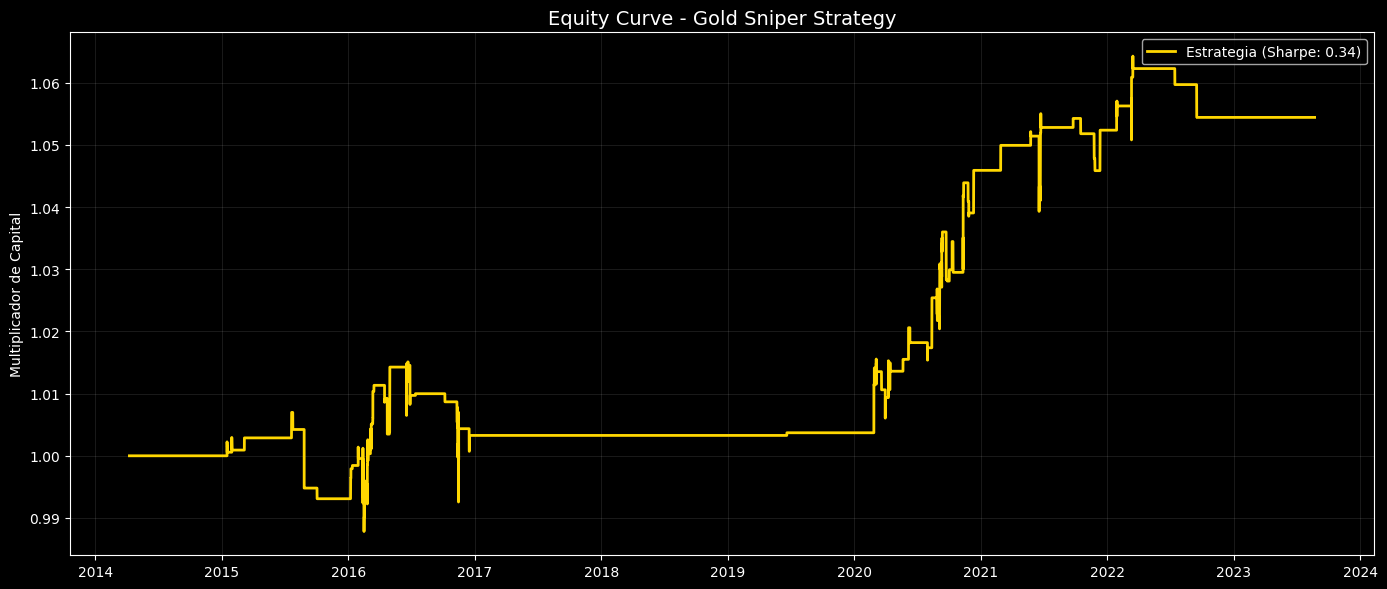

,datetime,actual,pred,prob_0,prob_1,prob_2,ret_real,close,signal,strat_ret,cum_strat
0,2014-04-08 23:00:00,1.0,1,0.197937,0.448337,0.353726,0.000632,1309.143448,0,0.0,1.000000
1,2014-04-09 02:00:00,1.0,1,0.227848,0.452668,0.319484,0.000386,1309.347573,0,0.0,1.000000
2,2014-04-09 03:00:00,2.0,1,0.186247,0.605319,0.208434,0.002578,1309.970630,0,0.0,1.000000
3,2014-04-09 04:00:00,2.0,1,0.146363,0.702699,0.150939,0.002035,1309.853073,0,0.0,1.000000
4,2014-04-09 05:00:00,0.0,1,0.128242,0.735153,0.136605,-0.000792,1313.347827,0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
99955,2023-08-22 04:00:00,1.0,1,0.164487,0.708565,0.126948,0.000507,1923.760959,0,0.0,1.054418
99956,2023-08-22 05:00:00,1.0,1,0.161775,0.711122,0.127104,0.000034,1923.165122,0,0.0,1.054418
99957,2023-08-22 06:00:00,1.0,1,0.182462,0.674161,0.143377,-0.000327,1924.736169,0,0.0,1.054418
99958,2023-08-22 07:00:00,2.0,1,0.231116,0.577138,0.191745,0.002002,1923.230091,0,0.0,1.054418


In [52]:
bt_triple.run(conf_threshold=0.52, horizonte=2, sl_ticks=40)


📊 BACKTEST SNIPER [Modo: TRI]
💰 Sharpe Ratio:     0.3194
📉 Max Drawdown:     -2.24%
📈 Retorno Total:    5.09%
🎯 Win Rate:         48.77%
⚖️ Total Trades:     365
📅 Periodo:          2014-04-08 al 2023-08-22


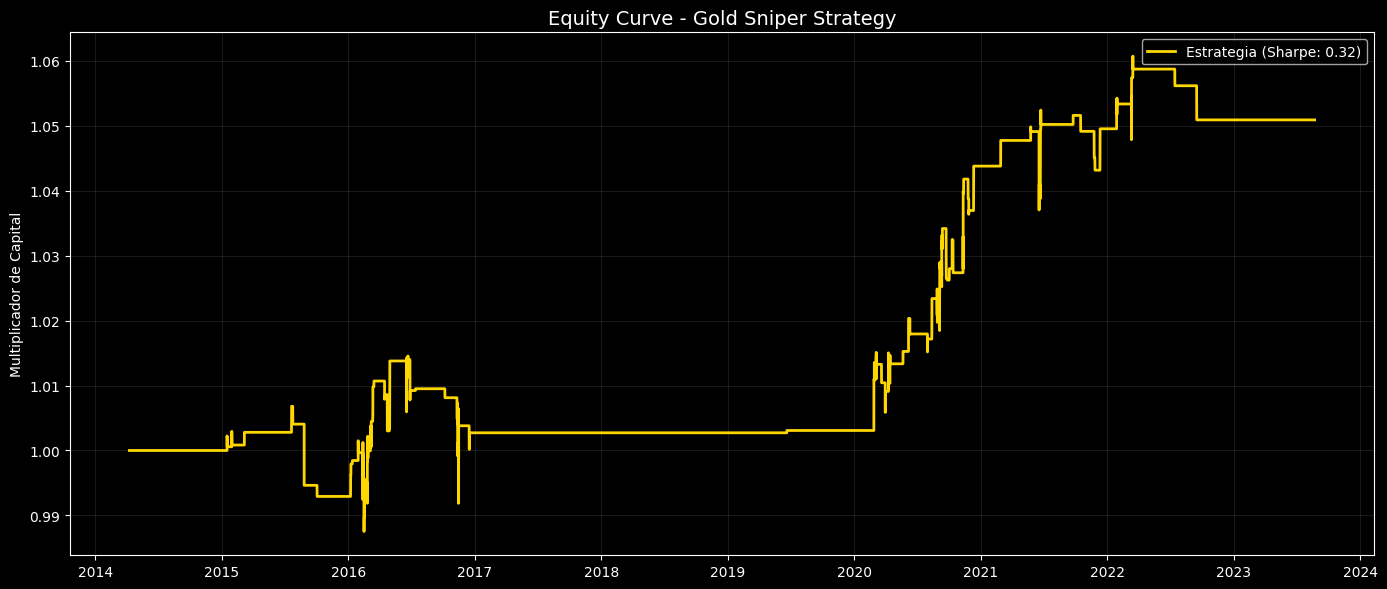

,datetime,actual,pred,prob_0,prob_1,prob_2,ret_real,close,signal,strat_ret,cum_strat
0,2014-04-08 23:00:00,1.0,1,0.197937,0.448337,0.353726,0.000632,1309.143448,0,0.0,1.000000
1,2014-04-09 02:00:00,1.0,1,0.227848,0.452668,0.319484,0.000386,1309.347573,0,0.0,1.000000
2,2014-04-09 03:00:00,2.0,1,0.186247,0.605319,0.208434,0.002578,1309.970630,0,0.0,1.000000
3,2014-04-09 04:00:00,2.0,1,0.146363,0.702699,0.150939,0.002035,1309.853073,0,0.0,1.000000
4,2014-04-09 05:00:00,0.0,1,0.128242,0.735153,0.136605,-0.000792,1313.347827,0,0.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...
99955,2023-08-22 04:00:00,1.0,1,0.164487,0.708565,0.126948,0.000507,1923.760959,0,0.0,1.050916
99956,2023-08-22 05:00:00,1.0,1,0.161775,0.711122,0.127104,0.000034,1923.165122,0,0.0,1.050916
99957,2023-08-22 06:00:00,1.0,1,0.182462,0.674161,0.143377,-0.000327,1924.736169,0,0.0,1.050916
99958,2023-08-22 07:00:00,2.0,1,0.231116,0.577138,0.191745,0.002002,1923.230091,0,0.0,1.050916


In [55]:
bt_triple.run(
    conf_threshold=0.52, 
    horizonte=2,      # 2 horas de permanencia
    sl_ticks=40,       # Stop Loss 4$
    tp_ticks=120,      # Take Profit amplio (12$) para dejar correr las tendencias
    cost_ticks=1.5     # Spread + Comisión real
)

In [ ]:
class SniperInstitutionalEngine:
    def __init__(self, df, config, initial_capital=1000000.0):
        self.df = df.copy()
        self.c = config
        self.initial_capital = initial_capital
        # Aseguramos que el índice sea datetime
        self.df['datetime'] = pd.to_datetime(self.df['datetime'])
        
    def run(self, conf_start=0.52, conf_step=0.05, max_contracts=5):
        df = self.df.sort_values('datetime').reset_index(drop=True)
        
        # Columnas de seguimiento
        n = len(df)
        equity = np.zeros(n)
        equity[0] = self.initial_capital
        pnl_record = np.zeros(n)
        pos_record = np.zeros(n)
        
        # Estado de la operativa
        pos = 0 # Contratos actuales
        entry_prices = []
        sl_price = 0
        tp_price = 0
        
        for i in range(1, n):
            row = df.iloc[i]
            current_price = row['close']
            dt = row['datetime']
            
            # --- A. LÓGICA DE CIERRE DIARIO (PRE-BREAK) ---
            # Si tus datos están en hora española (CET), el break es de 00:00 a 01:00
            # Cerramos a las 23:45 para evitar el ensanchamiento del spread
            is_near_break = (dt.hour == 23 and dt.minute >= 45)
            
            # --- B. GESTIÓN DE SALIDAS (POSICIÓN ABIERTA) ---
            if pos != 0:
                avg_entry = np.mean(entry_prices)
                
                # Condiciones de salida
                hit_sl = (pos > 0 and current_price <= sl_price) or (pos < 0 and current_price >= sl_price)
                hit_tp = (pos > 0 and current_price >= tp_price) or (pos < 0 and current_price <= tp_price)
                
                # Señal contraria o paso a Neutral (prob_1)
                signal_flip = (pos > 0 and row['prob_0'] > row['prob_2']) or (pos < 0 and row['prob_2'] > row['prob_0'])
                is_neutral = (row['prob_1'] > row['prob_0']) and (row['prob_1'] > row['prob_2'])
                
                if hit_sl or hit_tp or signal_flip or is_neutral or is_near_break:
                    exec_price = sl_price if hit_sl else (tp_price if hit_tp else current_price)
                    
                    # Cálculo PnL: (Precio - Entrada) * Multiplicador * Contratos
                    trade_pnl = (exec_price - avg_entry) * self.c['multiplier'] * pos
                    fees = abs(pos) * self.c['approx_total_fee_per_side']
                    pnl_record[i] = trade_pnl - fees
                    
                    # Reset
                    pos = 0
                    entry_prices = []
                    sl_price = 0
                    tp_price = 0
            
            # --- C. LÓGICA DE ENTRADA Y PIRAMIDACIÓN (STRIKES) ---
            if not is_near_break:
                conf_buy = row['prob_2']
                conf_sell = row['prob_0']
                
                # Cálculo de cuántos contratos "deberíamos" tener (Strikes)
                # Ejemplo: 0.52 -> 1, 0.57 -> 2, 0.62 -> 3...
                if conf_buy > conf_start:
                    target_pos = int((conf_buy - conf_start) / conf_step) + 1
                    target_pos = min(target_pos, max_contracts)
                    
                    # Solo añadimos si no tenemos ya esa cantidad y el margen lo permite
                    if pos < target_pos:
                        if pos < 0: # Teníamos cortos, cerramos primero (se gestionó arriba)
                            pass 
                        else:
                            new_contracts = target_pos - pos
                            for _ in range(new_contracts):
                                # Verificamos margen inicial disponible
                                if (abs(pos) + 1) * self.c['initial_margin'] < equity[i-1]:
                                    pos += 1
                                    entry_prices.append(current_price)
                                    pnl_record[i] -= self.c['approx_total_fee_per_side']
                                    # SL y TP Dinámicos (40 ticks SL / 120 ticks TP)
                                    sl_price = current_price - (40 * self.c['tick_size'])
                                    tp_price = current_price + (120 * self.c['tick_size'])

                elif conf_sell > conf_start:
                    target_pos = -(int((conf_sell - conf_start) / conf_step) + 1)
                    target_pos = max(target_pos, -max_contracts)
                    
                    if pos > target_pos:
                        if pos > 0: pass
                        else:
                            new_contracts = abs(target_pos - pos)
                            for _ in range(new_contracts):
                                if (abs(pos) + 1) * self.c['initial_margin'] < equity[i-1]:
                                    pos -= 1
                                    entry_prices.append(current_price)
                                    pnl_record[i] -= self.c['approx_total_fee_per_side']
                                    sl_price = current_price + (40 * self.c['tick_size'])
                                    tp_price = current_price - (120 * self.c['tick_size'])

            # Actualizar Equity y Registro de posición
            equity[i] = equity[i-1] + pnl_record[i]
            pos_record[i] = pos
            
        df['equity'] = equity
        df['pos'] = pos_record
        return df

In [ ]:
import pandas as pd
import glob

def merge_gold_contracts(pattern="GOLD_FUT_*.csv"):
    files = glob.glob(pattern)
    if not files:
        print("❌ No se encontraron archivos CSV.")
        return None
    
    all_dfs = []
    for f in files:
        temp_df = pd.read_csv(f)
        
        # EL CAMBIO ESTÁ AQUÍ: Añadimos utc=True para estandarizar
        temp_df['datetime'] = pd.to_datetime(temp_df['datetime'], utc=True)
        
        # Opcional: Si prefieres trabajar sin el offset "+00:00" en el objeto, 
        # puedes quitar la zona horaria después de normalizar:
        # temp_df['datetime'] = temp_df['datetime'].dt.tz_localize(None)
        
        all_dfs.append(temp_df)
    
    # 2. Concatenar y ordenar
    df_total = pd.concat(all_dfs).sort_values('datetime')
    
    # 3. Eliminar duplicados
    df_total = df_total.drop_duplicates(subset=['datetime'], keep='last')
    
    # 4. Calcular retornos (evitando saltos bruscos entre contratos)
    # Es mejor usar log-returns para series temporales financieras
    df_total['ret_real'] = np.log(df_total['close'] / df_total['close'].shift(1))
    
    df_total = df_total.dropna().reset_index(drop=True)
    
    print(f"✅ Unificación completada. Total velas: {len(df_total)}")
    print(f"📅 Rango: {df_total['datetime'].min()} a {df_total['datetime'].max()}")
    
    return df_total

# Ejecutar de nuevo
df_real_gold = merge_gold_contracts()

✅ Unificación completada. Total velas: 2843
📅 Rango: 2025-09-28 23:00:00+00:00 a 2026-03-27 15:00:00+00:00


In [58]:
import json
import os
from datetime import datetime

def log_experiment_to_json(model_name, run_id, subrun_id, config, metrics, feature_list, folder_path, json_filename="experiments_registry.json"):
    """
    Registra un experimento en un archivo JSON centralizado.
    """
    # 1. Preparar la nueva entrada
    new_entry = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "metrics": metrics,
        "feature_count": len(feature_list),
        "features": feature_list,
        "artifacts": {
            "model_path": os.path.join(folder_path, "model.pth"),
            "scaler_path": os.path.join(folder_path, "scaler.pkl")
        }
    }

    # 2. Cargar datos existentes o crear diccionario nuevo
    if os.path.exists(json_filename):
        with open(json_filename, "r") as f:
            data = json.load(f)
    else:
        data = {}

    # 3. Navegar/Crear la estructura jerárquica
    if model_name not in data:
        data[model_name] = {
            "type": config.get("model_type", "LSTM/GRU"),
            "weights": config.get("weights_mode", "dynamic"),
            "global_params": config.get("global", {}),
            "runs": {}
        }
    
    if run_id not in data[model_name]["runs"]:
        data[model_name]["runs"][run_id] = {
            "config_at_run": config,
            "subruns": {}
        }

    # Añadir la subrun (ej: subrun_1 para All Features, subrun_2 para Top N)
    data[model_name]["runs"][run_id]["subruns"][subrun_id] = new_entry

    # 4. Guardar físicamente el JSON
    with open(json_filename, "w") as f:
        json.dump(data, f, indent=4)
    
    print(f"📝 Registro actualizado en {json_filename} para {model_name} -> {subrun_id}")

In [59]:
import joblib

def save_model_artifacts(model, scaler, folder_path):
    """
    Guarda el archivo .pth del modelo y el .pkl del escalador.
    """
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
        print(f"📁 Carpeta creada: {folder_path}")

    # Guardar pesos de PyTorch
    model_path = os.path.join(folder_path, "model.pth")
    torch.save(model.state_dict(), model_path)
    
    # Guardar escalador
    scaler_path = os.path.join(folder_path, "scaler.pkl")
    joblib.dump(scaler, scaler_path)
    
    print(f"💾 Pesos y Escalador guardados en {folder_path}")

In [60]:
# 1. Definir rutas
MODEL_NAME = "XAU_GRU_bin_V2"
RUN_ID = "run_60min_wavelet"
SUBRUN_ID = "subrun_top_25"
SAVE_PATH = f"Models/{MODEL_NAME}/{RUN_ID}/{SUBRUN_ID}"

# 3. Guardar archivos (pth y pkl)
save_model_artifacts(model_bin_second, sc_bin_second, SAVE_PATH)

MODEL_NAME = "XAU_GRU_triple_V2"
RUN_ID = "run_60min_wavelet"
SUBRUN_ID = "subrun_top_25"
SAVE_PATH = f"Models/{MODEL_NAME}/{RUN_ID}/{SUBRUN_ID}"
save_model_artifacts(model_triple_second, sc_triple_second, SAVE_PATH)

MODEL_NAME = "XAU_GRU_bin_V2"
RUN_ID = "run_60min_wavelet"
SUBRUN_ID = "subrun_all_features"
SAVE_PATH = f"Models/{MODEL_NAME}/{RUN_ID}/{SUBRUN_ID}"
save_model_artifacts(model_bin, sc_bin, SAVE_PATH)

MODEL_NAME = "XAU_GRU_V2"
RUN_ID = "run_60min_wavelet"
SUBRUN_ID = "subrun_all_features"
SAVE_PATH = f"Models/{MODEL_NAME}/{RUN_ID}/{SUBRUN_ID}"
save_model_artifacts(model_triple, sc_triple, SAVE_PATH)

# 2. Recopilar métricas de tu evaluación
# mis_metricas = {
#     "accuracy": 0.51,
#     "precision_buy": 0.35,
#     "recall_neutral": 0.11,
#     "profit_factor": 1.45,
#     "sharpe": 1.82,
#     "max_dd": -0.12
# }

# 4. Registrar en el JSON (puedes pasarle tu diccionario 'config' tal cual lo tienes)
# log_experiment_to_json(
#     model_name=MODEL_NAME,
#     run_id=RUN_ID,
#     subrun_id=SUBRUN_ID,
#     config=config, # El diccionario que pusiste en tu mensaje
#     metrics=mis_metricas,
#     feature_list=final_features_triple, # La lista filtrada por VIF
#     folder_path=SAVE_PATH
# )

📁 Carpeta creada: Models/XAU_GRU_bin_V2/run_60min_wavelet/subrun_top_25
💾 Pesos y Escalador guardados en Models/XAU_GRU_bin_V2/run_60min_wavelet/subrun_top_25
📁 Carpeta creada: Models/XAU_GRU_triple_V2/run_60min_wavelet/subrun_top_25
💾 Pesos y Escalador guardados en Models/XAU_GRU_triple_V2/run_60min_wavelet/subrun_top_25
📁 Carpeta creada: Models/XAU_GRU_bin_V2/run_60min_wavelet/subrun_all_features
💾 Pesos y Escalador guardados en Models/XAU_GRU_bin_V2/run_60min_wavelet/subrun_all_features
📁 Carpeta creada: Models/XAU_GRU_V2/run_60min_wavelet/subrun_all_features
💾 Pesos y Escalador guardados en Models/XAU_GRU_V2/run_60min_wavelet/subrun_all_features


In [62]:
def load_model_artifacts(folder_path, model_class, **model_params):
    """
    Carga el modelo y el escalador desde la carpeta especificada.
    """
    # 1. Cargar el escalador
    scaler_path = os.path.join(folder_path, "scaler.pkl")
    if os.path.exists(scaler_path):
        scaler = joblib.load(scaler_path)
        print("✅ Escalador cargado.")
    else:
        raise FileNotFoundError("No se encontró el archivo del escalador.")

    # 2. Instanciar la clase del modelo
    # Pasa aquí los mismos parámetros que usaste al entrenar (input_dim, hidden_dim, etc.)
    model = model_class(**model_params)

    # 3. Cargar los pesos (.pth)
    model_path = os.path.join(folder_path, "model.pth")
    if os.path.exists(model_path):
        # map_location=torch.device('cpu') por si lo cargamos en una máquina sin GPU
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.to(device)
        model.eval() # IMPORTANTE: Poner el modelo en modo evaluación
        print(f"✅ Modelo cargado y puesto en modo EVAL en {device}.")
    else:
        raise FileNotFoundError("No se encontró el archivo model.pth.")

    return model, scaler

# --- EJEMPLO DE USO Y VERIFICACIÓN ---

# Define aquí los parámetros que usaste en tu GoldAttentionGRU_Triple
params = {
    'input_dim': len(FEATURE_COLS_TRIPLE), 
    'output_dim': 3,
    'hidden_dim': 256, # Tu clase usa 256 por defecto
    'num_layers': 2,   # Se llama num_layers, no layer_dim
    'dropout': 0.3
}

try:
    # 1. Cargamos
    mi_modelo, mi_escalador = load_model_artifacts(
        folder_path=SAVE_PATH, 
        model_class=GoldAttentionGRU_Triple, 
        **params
    )

    # 2. PRUEBA DE FUEGO: Creamos un tensor aleatorio con el shape de entrada
    # [Batch_Size, Lookback, Features] -> Ejemplo: [1, 48, num_features]
    test_input = torch.randn(1, 48, params['input_dim']).to(next(mi_modelo.parameters()).device)
    
    with torch.no_grad():
        output = mi_modelo(test_input)
        print("\n🚀 ¡Prueba exitosa!")
        print(f"Salida del modelo (Probabilidades): {output}")
        print(f"Predicción (Clase): {torch.argmax(output, dim=1).item()}")

except Exception as e:
    print(f"❌ Error al cargar o probar el modelo: {e}")

✅ Escalador cargado.
✅ Modelo cargado y puesto en modo EVAL en cuda.

🚀 ¡Prueba exitosa!
Salida del modelo (Probabilidades): tensor([[-0.2186,  0.1117, -0.3151]], device='cuda:0')
Predicción (Clase): 1


In [11]:
# Calculamos la volatilidad media (ATR simplificado) para que el umbral sea lógico
volatilidad_media = df_final_dict[f'{MINUTES}min']['target_ret_30m'].abs().mean()
print(f"Volatilidad media cada 30 min: {volatilidad_media:.5f}")

# Umbral: Solo queremos operar si el movimiento esperado es mayor que la media
threshold = volatilidad_media * 0.7

Volatilidad media cada 30 min: 0.00222


In [12]:
# Definir el umbral (ajustar según volatilidad)
# threshold = 0.0005 

def label_triple(ret):
    if ret > threshold:
        return 2 # Buy
    elif ret < -threshold:
        return 0 # Sell
    else:
        return 1 # Neutral

df_final_dict[f'{MINUTES}min']['target_triple'] = df_final_dict[f'{MINUTES}min']['target_ret_30m'].apply(label_triple)

# Verifica el balance de clases
print(df_final_dict[f'{MINUTES}min']['target_triple'].value_counts(normalize=True))

target_triple
1    0.532873
2    0.237340
0    0.229787
Name: proportion, dtype: float64


In [13]:
class GoldLSTM_Triple(nn.Module):
    def __init__(self, input_dim, hidden_dim=128, num_layers=2, dropout=0.3):
        super(GoldLSTM_Triple, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout)
        
        self.batch_norm = nn.BatchNorm1d(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, 32)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(32, 3) # Salida para: [Sell, Neutral, Buy]

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :] 
        
        out = self.batch_norm(out)
        out = self.fc1(out)
        out = self.relu(out)
        out = self.dropout(out)
        return self.fc2(out) # Retorna logits

In [14]:
class GoldLSTM_V2(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=1, dropout=0.2): # Más ligero
        super(GoldLSTM_V2, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, 3) # Directo a las 3 clases

    def forward(self, x):
        # Usamos solo el último estado oculto
        _, (hn, _) = self.lstm(x)
        out = self.dropout(hn[-1])
        return self.fc(out)

In [15]:
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Definir Pesos de Clase (Penalizamos más el fallo en Buy/Sell)
# Clase 0 (Sell): Peso 2.5 | Clase 1 (Neutral): Peso 1.0 | Clase 2 (Buy): Peso 2.5
class_weights = torch.tensor([2.5, 1.0, 2.5], dtype=torch.float32).to("cuda")

def run_walk_forward_triple_final(df, feature_cols, target_col='target_triple'):
    device = torch.device("cuda")
    scaler_amp = torch.amp.GradScaler('cuda')
    all_predictions = []
    
    # Parámetros óptimos para tu 3060
    # train_size=5000, test_size=1000, step=500, lookback=24
    train_size, test_size, step = 5000, 1000, 500
    lookback, epochs, batch_size = 24, 10, 512 # Subimos epochs y batch_size
    
    df_wf = df.copy().sort_values('datetime').reset_index(drop=True)
    
    for start in tqdm(range(0, len(df_wf) - train_size - test_size, step), desc="Training Triple"):
        # ... [Segmentación y Escalado RobustScaler igual que antes] ...
        end_train = start + train_size
        end_test = end_train + test_size
        
        # --- Preprocesado y Escalado ---
        train_df = df_wf.iloc[start:end_train].copy()
        test_df = df_wf.iloc[end_train:end_test].copy()
        
        sc = RobustScaler()
        train_df[feature_cols] = sc.fit_transform(train_df[feature_cols])
        test_df[feature_cols] = sc.transform(test_df[feature_cols])
        
        X_train, y_train = create_lstm_dataset(train_df, feature_cols, target_col, lookback)
        X_test, y_test = create_lstm_dataset(test_df, feature_cols, target_col, lookback)
        
        # Preparar Tensores
        X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
        y_train_t = torch.tensor(y_train, dtype=torch.long).to(device) # LONG para CrossEntropy
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        
        loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
        
        # Modelo
        model = GoldLSTM_Triple(input_dim=len(feature_cols)).to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.0005)
        criterion = nn.CrossEntropyLoss(weight=class_weights) # <--- PESOS AQUÍ
        
        # Entrenamiento con AMP
        model.train()
        for epoch in range(epochs):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                with torch.amp.autocast('cuda'):
                    outputs = model(batch_X)
                    loss = criterion(outputs, batch_y)
                scaler_amp.scale(loss).backward()
                scaler_amp.step(optimizer)
                scaler_amp.update()
        
        # Predicción
        model.eval()
        with torch.no_grad():
            logits = model(X_test_t)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            
        # ... [Guardar en DataFrame res_df como el anterior] ...
        res_df = pd.DataFrame({
            'datetime': df_wf['datetime'].iloc[end_train + lookback : end_test].values,
            'actual': y_test,
            'pred': preds,
            'prob_sell': probs[:, 0],
            'prob_neutral': probs[:, 1],
            'prob_buy': probs[:, 2],
            'ret_real': df_wf['target_ret_30m'].iloc[end_train + lookback : end_test].values
        })
        all_predictions.append(res_df)
        torch.cuda.empty_cache()
        print(f"✅ Ventana {df_wf['datetime'].iloc[start].date()} OK. Acc: {(preds == y_test).mean():.2%}")

    return pd.concat(all_predictions, ignore_index=True)

In [16]:
result_triple = run_walk_forward_triple_final(df_final_dict[f'{MINUTES}min'], FEATURE_COLUMNS)

Training Triple:   0%|          | 0/137 [00:00<?, ?it/s]

✅ Ventana 2010-09-21 OK. Acc: 40.47%
✅ Ventana 2010-10-20 OK. Acc: 41.70%
✅ Ventana 2010-11-18 OK. Acc: 38.83%
✅ Ventana 2010-12-17 OK. Acc: 37.81%
✅ Ventana 2011-01-18 OK. Acc: 35.35%
✅ Ventana 2011-02-16 OK. Acc: 35.35%
✅ Ventana 2011-03-17 OK. Acc: 40.37%
✅ Ventana 2011-04-15 OK. Acc: 38.93%
✅ Ventana 2011-05-17 OK. Acc: 43.55%
✅ Ventana 2011-06-15 OK. Acc: 40.68%
✅ Ventana 2011-07-15 OK. Acc: 39.45%
✅ Ventana 2011-08-15 OK. Acc: 42.11%
✅ Ventana 2011-09-13 OK. Acc: 48.16%
✅ Ventana 2011-10-12 OK. Acc: 45.39%
✅ Ventana 2011-11-10 OK. Acc: 42.73%
✅ Ventana 2011-12-09 OK. Acc: 44.88%
✅ Ventana 2012-01-11 OK. Acc: 48.98%
✅ Ventana 2012-02-09 OK. Acc: 51.23%
✅ Ventana 2012-03-12 OK. Acc: 50.51%
✅ Ventana 2012-04-11 OK. Acc: 54.61%
✅ Ventana 2012-05-10 OK. Acc: 50.20%
✅ Ventana 2012-06-08 OK. Acc: 42.83%
✅ Ventana 2012-07-09 OK. Acc: 44.67%
✅ Ventana 2012-08-07 OK. Acc: 38.32%
✅ Ventana 2012-09-05 OK. Acc: 36.27%
✅ Ventana 2012-10-04 OK. Acc: 36.78%
✅ Ventana 2012-11-02 OK. Acc: 38.32%
✅

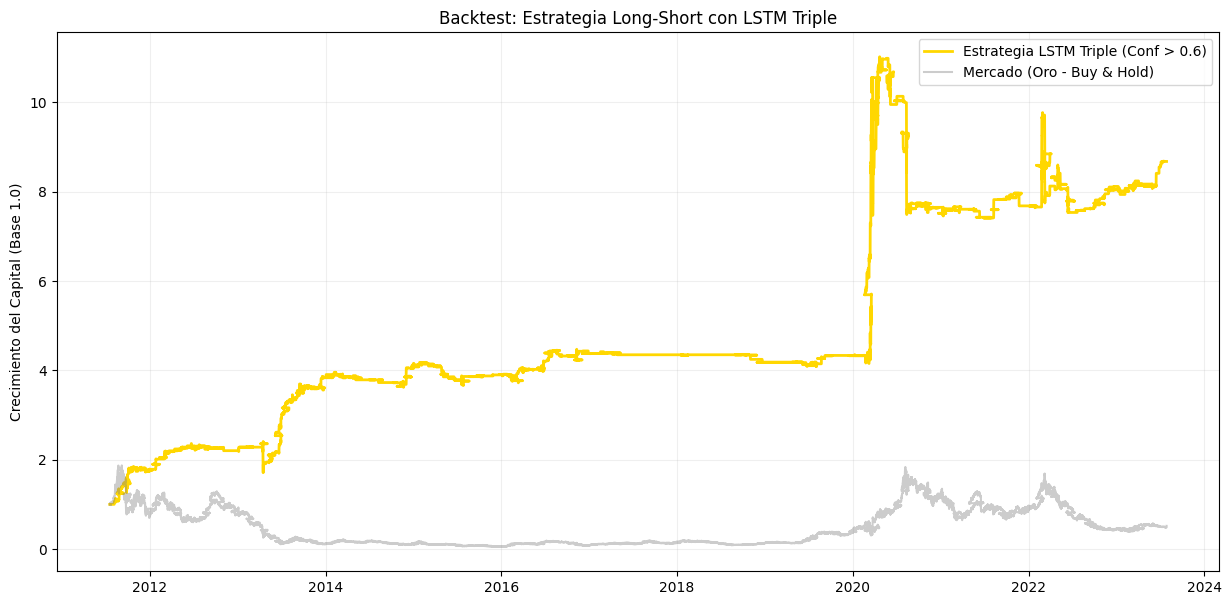

------------------------------
💰 NUEVO Sharpe Ratio: 1.61
📈 Retorno Total: 767.46%
🎯 Win Rate (de los trades): 55.68%
📊 Ratio de Operatividad: 2.92% (tiempo en mercado)
📉 Total de Trades: 3906 de 133712 velas
------------------------------


In [17]:
plot_triple_trading_results(result_triple, 0.6)

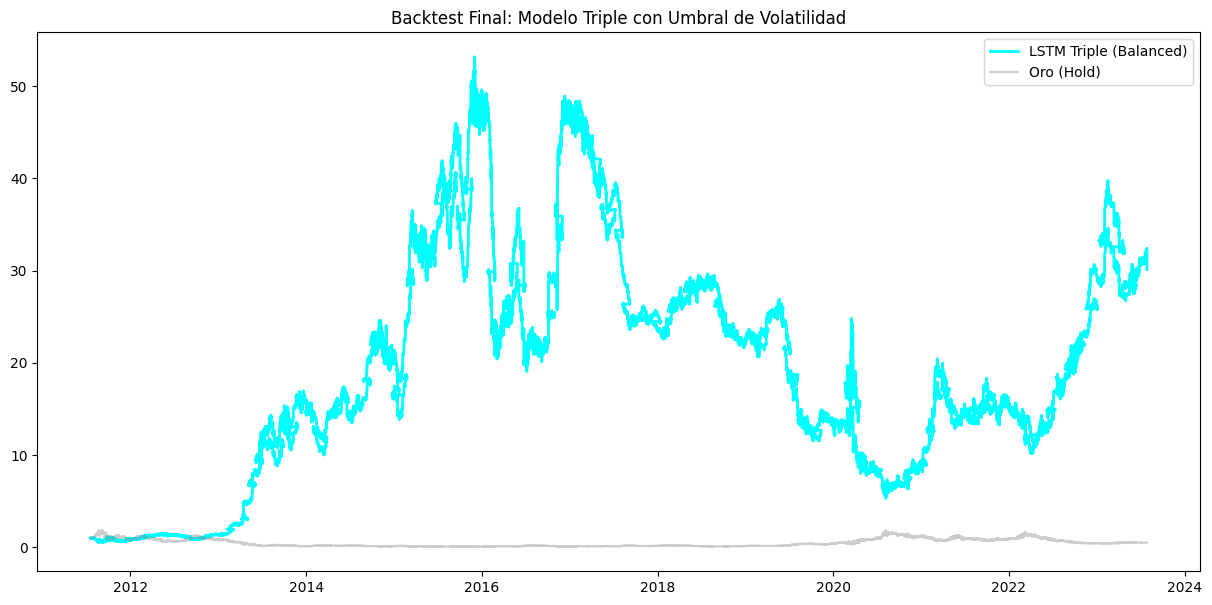

💰 Sharpe Ratio Esperado: 1.04


In [18]:
plot_triple_final_comparison(result_triple)

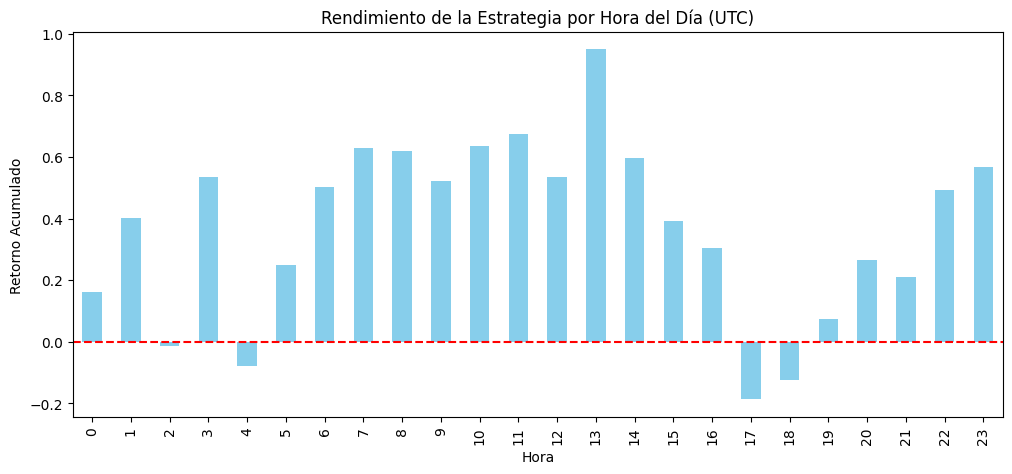

In [19]:
analyze_by_hour(result_triple)

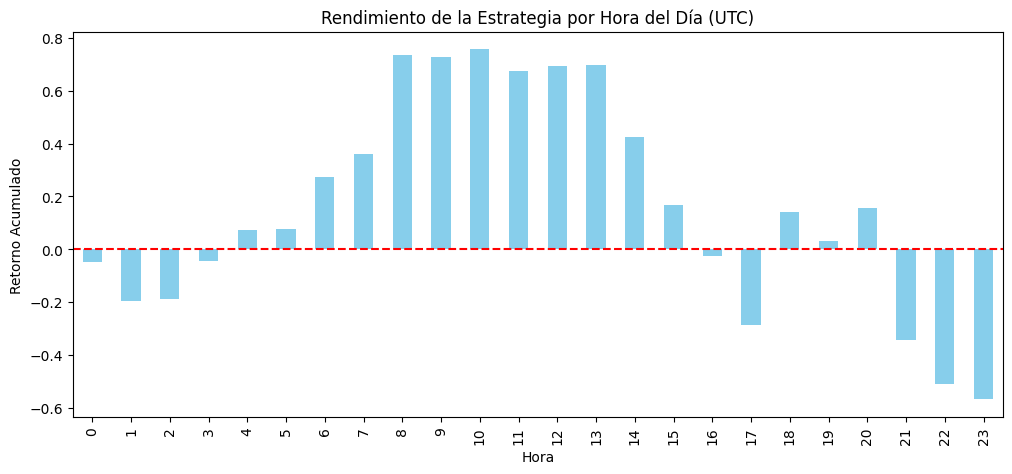

In [20]:
analyze_by_hour(result_torch)

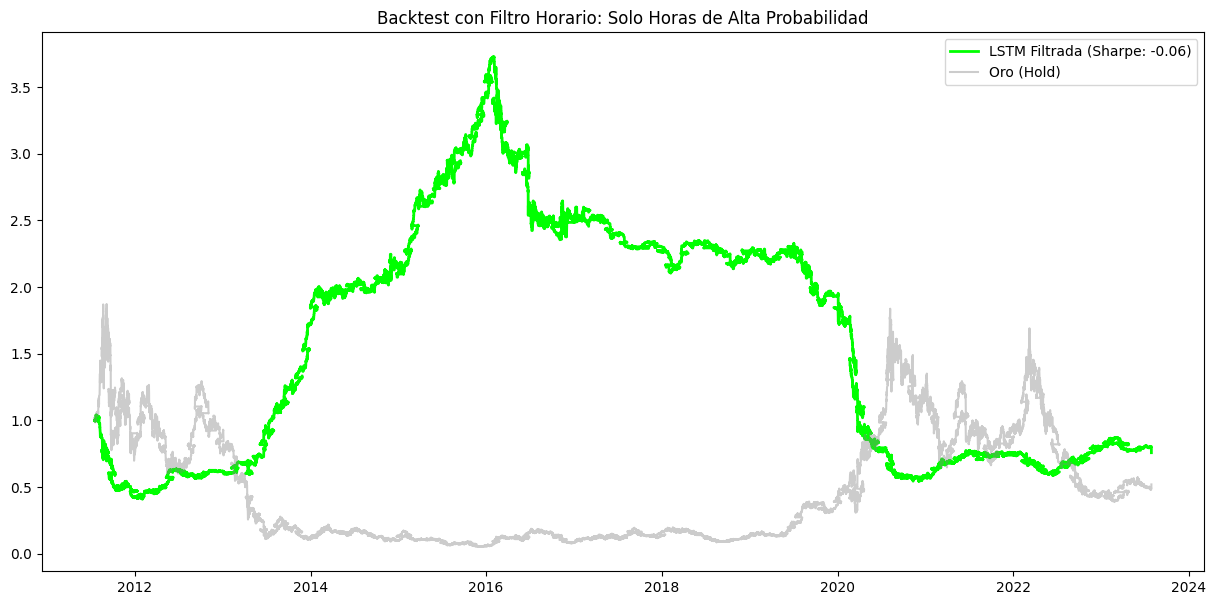

🚀 Sharpe Ratio con Filtro: -0.06


In [21]:
plot_backtest_filtrado(result_triple)

In [22]:
print(f"📊 El Sharpe Ratio REAL de este modelo es: {calculate_real_sharpe_binary(result_torch):.4f}")

✅ Análisis del Modelo Binario:
-------------------------------
💰 Retorno Acumulado Estrategia: 33.8851
📈 Retorno Acumulado Mercado:    0.5192
📊 El Sharpe Ratio REAL de este modelo es: 1.2874


In [23]:
calculate_sharpe_triple(result_triple)

📈 Resultado Final:
-------------------
💰 Sharpe Ratio: 2.2582
🚀 Retorno Total: 367864.39%
⚖️ Operaciones totales: 82899 de 133712


np.float64(2.2581588691014574)

In [24]:
calculate_final_binary_sharpe(result_torch)

📊 --- RESULTADOS BINARIOS ---
💰 Sharpe Ratio: 1.2874
📉 Volatilidad Anual: 27.75%
📈 Retorno Final: 33.8851
-------------------------------


np.float64(1.2873641565878773)

In [25]:
result_torch_filtered = apply_time_filter(result_torch) # Usa el df que tiene prob_up


🚀 Sharpe Original: 0.6245
💎 Sharpe Filtrado: 0.9247


In [26]:
stress_test_with_costs(result_torch_filtered, 0.0002)


🧪 --- STRESS TEST (1 TICK COST) ---
📉 Sharpe con Costes: -0.0024
💰 Retorno Final tras costes: 0.8032
🚪 Total de entradas pagadas: 10080
------------------------------------


np.float64(-0.0024124267457365195)

In [27]:
# Sobre el dataframe original de 3028 operaciones
avg_ret_per_trade = result_torch_filtered[result_torch_filtered['signal_final'] == 1]['ret_real'].mean()
print(f"Retorno medio por trade: {avg_ret_per_trade:.6f}")

Retorno medio por trade: 0.000053


In [ ]:
close_map = df_final_dict[f'{MINUTES}min'].set_index('datetime')['close']
result_torch_filtered['close'] = result_torch_filtered['datetime'].map(close_map)

In [33]:
result_triple['close'] = result_triple['datetime'].map(close_map)

In [29]:
run_backtest_pro(result_torch_filtered, tp_ticks=8, sl_ticks=4)

🏆 Resultado con Gestión de Riesgo (TP:8 / SL:4 ticks):
📊 Sharpe Neto: 7.8178
💰 Retorno Total: 7.4150


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002130,1.002130,1.002130,1,4,1,0.002130,1594.5,0.000439
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001754,1.003888,1.003888,1,5,1,0.001754,1594.6,0.000439
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001628,1.005522,1.005522,1,6,1,0.001628,1595.8,0.000439
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000876,1.006403,1.006403,1,7,1,0.000876,1597.9,0.000438
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001564,1.007977,1.007977,1,8,1,0.001564,1597.4,0.000438
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000817,31.993982,0.490243,1,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000460,31.979280,0.490018,1,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020065,32.620940,0.499850,1,21,1,0.020065,1958.8,0.000357
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018964,33.239576,0.509329,1,22,0,0.000000,1958.7,0.000000


In [30]:
run_backtest_managed_with_costs(result_torch_filtered, tp_ticks=40, sl_ticks=20, cost_in_ticks=2, tick_val=0.0001)

✅ TP: 40 | SL: 20 | Coste: 2 ticks
📊 Sharpe Neto Final: 15.9759
💰 Retorno Acumulado: 1.0225


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close,strat_ret_managed
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002130,1.002130,1.002130,1,4,1,0.002130,1594.5,0.000002
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001754,1.003888,1.003888,1,5,1,0.001754,1594.6,0.000002
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001628,1.005522,1.005522,1,6,1,0.001628,1595.8,0.000002
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000876,1.006403,1.006403,1,7,1,0.000876,1597.9,0.000002
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001564,1.007977,1.007977,1,8,1,0.001564,1597.4,0.000002
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000817,31.993982,0.490243,1,19,0,-0.000000,1960.3,0.000000
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000460,31.979280,0.490018,1,20,0,-0.000000,1959.0,0.000000
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020065,32.620940,0.499850,1,21,1,0.020065,1958.8,0.000002
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018964,33.239576,0.509329,1,22,0,0.000000,1958.7,0.000000


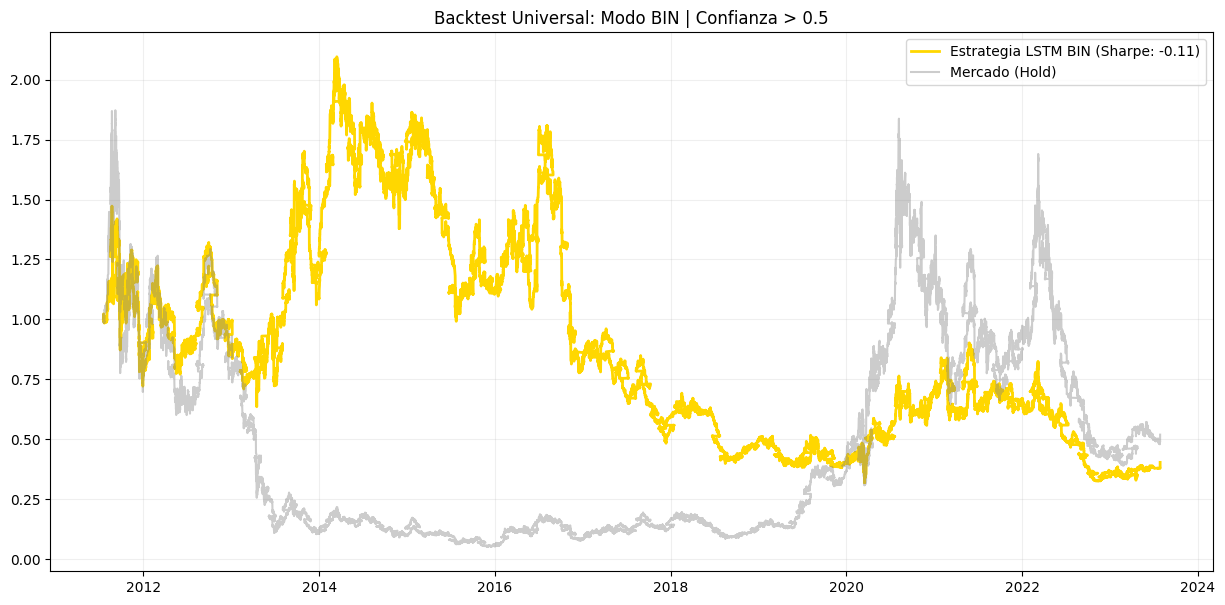

✅ Modo detectado: BIN
💰 Sharpe Ratio: -0.11
🎯 Win Rate: 49.07%


,datetime,actual,pred,prob_up,ret_real,strat_ret,cum_strat,cum_market,signal,hour,signal_final,strat_ret_filtered,close
0,2011-07-18 04:00:00,1,1,0.605594,0.002130,0.002067,1.002067,1.002130,1,4,1,0.002130,1594.5
1,2011-07-18 05:00:00,1,1,0.630598,0.001754,0.001692,1.003763,1.003888,1,5,1,0.001754,1594.6
2,2011-07-18 06:00:00,1,1,0.614935,0.001628,0.001565,1.005334,1.005522,1,6,1,0.001628,1595.8
3,2011-07-18 07:00:00,1,1,0.602117,0.000876,0.000813,1.006151,1.006403,1,7,1,0.000876,1597.9
4,2011-07-18 08:00:00,1,1,0.573846,0.001564,0.001501,1.007662,1.007977,1,8,1,0.001564,1597.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,0,1,0.503233,-0.000817,-0.000868,0.381225,0.490243,1,19,0,-0.000000,1960.3
133708,2023-07-28 20:00:00,0,1,0.525836,-0.000460,-0.000511,0.381030,0.490018,1,20,0,-0.000000,1959.0
133709,2023-07-28 21:00:00,1,1,0.570617,0.020065,0.020014,0.388656,0.499850,1,21,1,0.020065,1958.8
133710,2023-07-28 22:00:00,1,1,0.627106,0.018964,0.018913,0.396007,0.509329,1,22,0,0.000000,1958.7


In [31]:
plot_universal_backtest(result_torch_filtered)

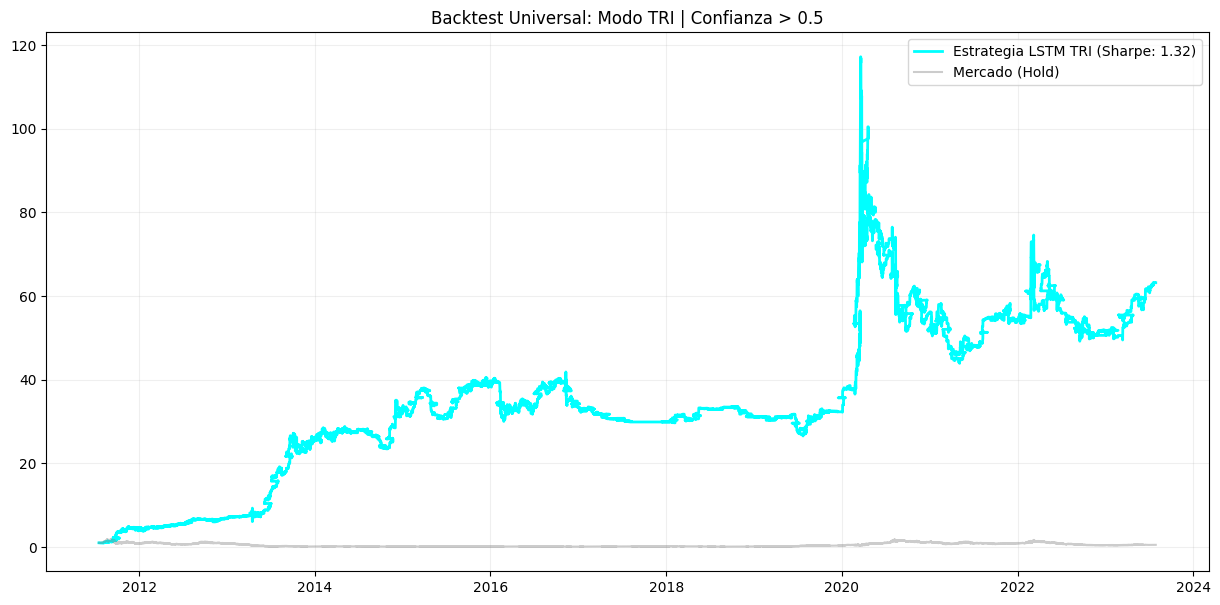

✅ Modo detectado: TRI
💰 Sharpe Ratio: 1.32
🎯 Win Rate: 52.66%


,datetime,actual,pred,prob_sell,prob_neutral,prob_buy,ret_real,close,signal,strat_ret,cum_strat,cum_market
0,2011-07-18 04:00:00,2,1,0.243226,0.460301,0.296473,0.002130,1594.5,0,0.0,1.000000,1.002130
1,2011-07-18 05:00:00,2,1,0.240879,0.445072,0.314049,0.001754,1594.6,0,0.0,1.000000,1.003888
2,2011-07-18 06:00:00,2,1,0.272804,0.404358,0.322838,0.001628,1595.8,0,0.0,1.000000,1.005522
3,2011-07-18 07:00:00,1,1,0.294130,0.384617,0.321253,0.000876,1597.9,0,0.0,1.000000,1.006403
4,2011-07-18 08:00:00,2,1,0.310271,0.367410,0.322320,0.001564,1597.4,0,0.0,1.000000,1.007977
...,...,...,...,...,...,...,...,...,...,...,...,...
133707,2023-07-28 19:00:00,1,2,0.388232,0.195632,0.416136,-0.000817,1960.3,0,-0.0,63.205513,0.490243
133708,2023-07-28 20:00:00,1,2,0.362487,0.202768,0.434746,-0.000460,1959.0,0,-0.0,63.205513,0.490018
133709,2023-07-28 21:00:00,2,2,0.333048,0.212014,0.454938,0.020065,1958.8,0,0.0,63.205513,0.499850
133710,2023-07-28 22:00:00,2,2,0.295610,0.219352,0.485038,0.018964,1958.7,0,0.0,63.205513,0.509329


In [34]:
plot_universal_backtest(result_triple)

In [31]:
import shap

def run_shap_analysis(model, train_loader, test_loader, feature_names):
    # 1. Preparar una muestra de datos (SHAP necesita tensores de fondo)
    # Tomamos el primer batch del train_loader como "background"
    batch_train_x, _ = next(iter(train_loader))
    batch_test_x, _ = next(iter(test_loader))
    
    # SHAP en PyTorch prefiere trabajar con tensores en CPU para la explicación
    model.cpu()
    background = batch_train_x[:100].cpu() # 100 ejemplos de fondo son suficientes
    test_samples = batch_test_x[:20].cpu()   # Explicamos las primeras 20 predicciones
    
    # 2. Inicializar el Explainer
    # DeepExplainer es ideal para redes neuronales
    explainer = shap.DeepExplainer(model, background)
    
    # 3. Calcular valores SHAP
    shap_values = explainer.shap_values(test_samples)
    
    # 4. Visualización
    print("📊 Generando Summary Plot...")
    # Como los datos son [batch, window, features], colapsamos el tiempo 
    # para ver la importancia general de la feature
    shap_values_collapsed = np.mean(np.abs(shap_values), axis=1) 
    
    shap.summary_plot(
        shap_values_collapsed, 
        features=test_samples.mean(dim=1).numpy(), 
        feature_names=feature_names,
        plot_type="bar"
    )

# Uso:
# run_shap_analysis(model_torch, train_loader, test_loader, feature_cols)

In [32]:
def explain_gold_model(model, df_test, feature_cols, lookback, scaler):
    # 1. Mover modelo a CPU y poner en modo entrenamiento (necesario para SHAP)
    model.cpu()
    model.train() 
    
    # Desactivamos capas que cambian el comportamiento en train
    for module in model.modules():
        if isinstance(module, (nn.Dropout, nn.BatchNorm1d)):
            module.eval()

    # 2. Preparación de datos (Directo en CPU)
    df_test_scaled = df_test.copy()
    df_test_scaled[feature_cols] = scaler.transform(df_test_scaled[feature_cols])
    
    X_test_shap, _ = create_lstm_dataset(df_test_scaled, feature_cols, target_col='target_bin', lookback=lookback)
    
    # Aseguramos tensores en CPU y Float32
    X_tensor = torch.tensor(X_test_shap, dtype=torch.float32).cpu()
    
    # 3. Muestras para el análisis
    # Usar 50 de fondo y 20 para explicar es suficiente para ver la tendencia
    background = X_tensor[:50] 
    test_samples = X_tensor[50:70] 
    
    # 4. Explicador SHAP
    # DeepExplainer funciona bien con LSTMs en CPU
    explainer = shap.DeepExplainer(model, background)
    
    # # 5. Cálculo de valores SHAP
    # print("⏳ Calculando valores SHAP (esto puede tardar un minuto en CPU)...")
    # shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # # 6. Procesamiento de dimensiones
    # # SHAP devuelve una lista por salida. Para clasificación binaria, tomamos [0] o [1]
    # shap_val_array = np.array(shap_values)
    
    # # Si la forma es [muestras, tiempo, features], promediamos el tiempo
    # if len(shap_val_array.shape) == 4: # [outputs, samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array[0]).mean(axis=1)
    # else: # [samples, time, features]
    #     shap_val_avg = np.abs(shap_val_array).mean(axis=1)

    # print("📊 SHAP Summary Plot:")
    # shap.summary_plot(
    #     shap_val_avg, 
    #     features=test_samples.mean(dim=1).numpy(), 
    #     feature_names=feature_cols,
    #     plot_type="bar" # Tipo barras para ver importancia clara
    # )
    # 5. Cálculo de valores SHAP
    shap_values = explainer.shap_values(test_samples, check_additivity=False)
    
    # 6. Normalización de dimensiones - VERSIÓN FINAL
    if isinstance(shap_values, list):
        # En clasificación binaria con DeepExplainer, a veces devuelve [muestras, tiempo, features, salidas]
        # Tomamos la salida 1
        shap_val_array = np.array(shap_values[-1]) 
    else:
        shap_val_array = np.array(shap_values)

    print(f"DEBUG: Shape original SHAP: {shap_val_array.shape}")

    # 7. Colapsar el Lookback (la dimensión del tiempo)
    # Si es (20, 24, 27) -> queremos (20, 27)
    if len(shap_val_array.shape) == 3:
        # Hacemos la media del impacto absoluto en las 24 horas
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
    elif len(shap_val_array.shape) == 4:
        # Si viene con (muestras, tiempo, features, salida)
        shap_val_final = np.abs(shap_val_array).mean(axis=1)
        if len(shap_val_final.shape) == 3: # (muestras, features, 1)
            shap_val_final = shap_val_final.reshape(shap_val_final.shape[0], shap_val_final.shape[1])
    else:
        shap_val_final = shap_val_array

    # 8. Preparar X_plot coincidente (20, 27)
    # Colapsamos el tiempo de las muestras de entrada también para el gráfico
    if len(test_samples.shape) == 3:
        X_plot = test_samples.mean(dim=1).numpy()
    else:
        X_plot = test_samples.numpy()

    print(f"✅ Ajuste final: SHAP {shap_val_final.shape} | Features {X_plot.shape}")

    # 9. Generar el gráfico
    shap.summary_plot(
        shap_val_final, 
        features=X_plot, 
        feature_names=feature_cols,
        plot_type="bar"
    )
    # OPCIONAL: Devolver el modelo a la GPU si vas a seguir usándolo
    # model.cuda()

In [33]:
df_test_reciente = df_final_dict[f'{MINUTES}min'].tail(1000).copy()

c:\Users\LIJUN\AppData\Local\Programs\Python\Python312\Lib\site-packages\shap\explainers\_deep\deep_pytorch.py:255: UserWarning: unrecognized nn.Module: LSTM
  warnings.warn(f"unrecognized nn.Module: {module_type}")


DEBUG: Shape original SHAP: (20, 24, 27, 1)
✅ Ajuste final: SHAP (20, 27) | Features (20, 27)


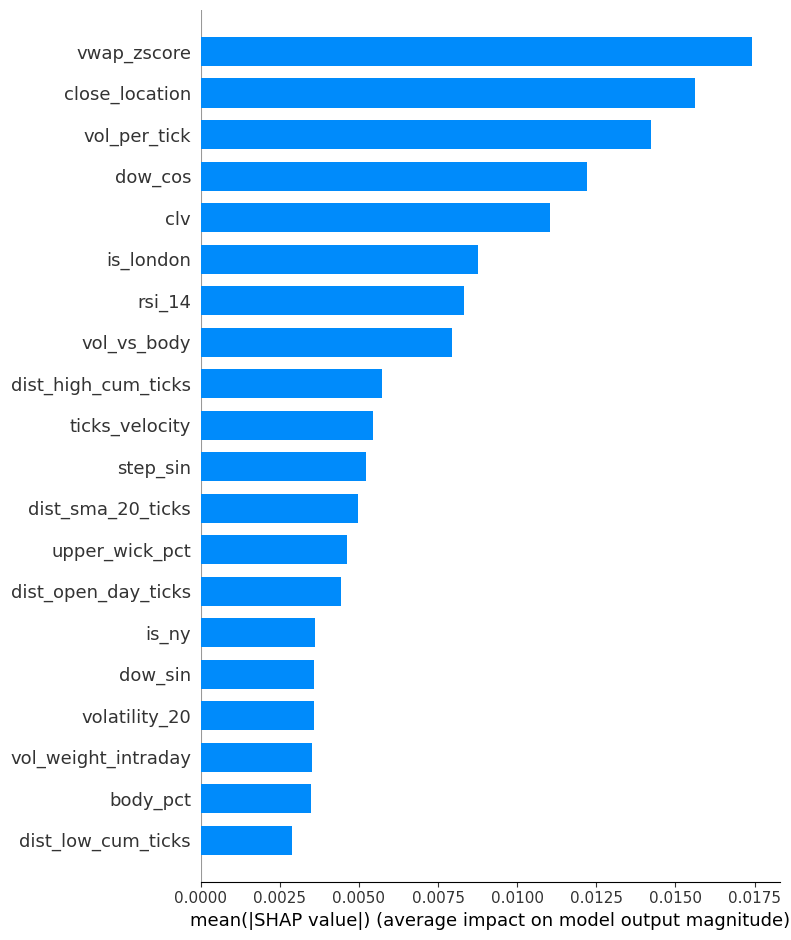

In [35]:
explain_gold_model(model, df_test_reciente, FEATURE_COLUMNS, 24, sc)

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

def sensitivity_scan(df_results, tp_range, sl_range, commission=1.0):
    """
    Prueba combinaciones de TP y SL para ver la estabilidad del Sharpe.
    """
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    
    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            pnl = []
            for _, row in df_results.iterrows():
                # Simulamos la lógica de salida
                # Si predice 1 (Compra)
                if row['pred'] == 1:
                    if row['ret_real'] >= tp:
                        pnl.append(tp - commission)
                    elif row['ret_real'] <= -sl:
                        pnl.append(-sl - commission)
                    else:
                        pnl.append(row['ret_real'] - commission)
                # Si predice 0 (Venta/Nada según tu modelo)
                # Ajustar aquí si tu modelo es binario 0/1 o -1/1
            
            if len(pnl) > 0:
                mean_pnl = np.mean(pnl)
                std_pnl = np.std(pnl) if np.std(pnl) > 0 else 1
                # Sharpe anualizado simplificado
                sharpe = (mean_pnl / std_pnl) * np.sqrt(252 * 10) # Ajustar según frecuencia
                matrix_sharpe[i, j] = sharpe

    # Visualización
    plt.figure(figsize=(10, 8))
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='RdYlGn')
    plt.title('Estabilidad del Sharpe: TP vs SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---
# Probamos TPs de 5 a 15 y SLs de 2 a 8
tps = np.arange(5, 16, 1)
sls = np.arange(2, 9, 1)



In [ ]:
# sensitivity_scan(result_torch_filtered, tps, sls)

KeyboardInterrupt: 

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

def sensitivity_scan_optimized(df_results, tp_range, sl_range, commission=1.0):
    """
    Versión vectorizada y optimizada para el escaneo de TP/SL.
    """
    # Convertimos columnas a arrays de numpy para velocidad máxima
    # Solo filtramos donde hubo predicción de compra (pred == 1)
    df_trades = df_results[df_results['pred'] == 1]
    returns = df_trades['ret_real'].values
    
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    
    # Pre-calculamos la raíz para anualizar
    annualization_factor = np.sqrt(252 * 10) # Ajustar según tu frecuencia real

    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Lógica vectorizada:
            # np.where(condicion, valor_si_true, valor_si_false)
            
            # 1. Si retorno >= TP, ganamos TP
            # 2. Si no, si retorno <= -SL, perdemos SL
            # 3. Si no, nos quedamos con el retorno real (salida por tiempo/cierre)
            pnl_vector = np.where(returns >= tp, tp, 
                         np.where(returns <= -sl, -sl, returns))
            
            # Restamos comisión a cada trade
            pnl_final = pnl_vector - commission
            
            if len(pnl_final) > 1:
                m = np.mean(pnl_final)
                s = np.std(pnl_final)
                if s > 0:
                    matrix_sharpe[i, j] = (m / s) * annualization_factor

    # Visualización (Idéntica a la anterior)
    plt.figure(figsize=(12, 9))
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='RdYlGn', center=0)
    plt.title('Mapa de Calor de Sharpe: Estabilidad TP vs SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---
tps = np.arange(5, 16, 1)
sls = np.arange(2, 9, 1)



In [44]:
# Ajusta el tick_size según tu activo (GC=0.1, CL=0.01, 6B=0.0001, etc.)
tick_size = 0.1 

# Creamos una columna nueva en ticks
result_torch_filtered['ret_ticks'] = result_torch_filtered['ret_real'] / tick_size

In [45]:
def run_full_strategy_scan(df_results, tp_range, sl_range, commission=1.0):
    # Filtramos solo donde el modelo dio señal de entrada
    df_trades = df_results[df_results['pred'] == 1].copy()
    
    # IMPORTANTE: Usamos la columna en TICKS
    returns = df_trades['ret_ticks'].values 
    
    matrix_sharpe = np.zeros((len(sl_range), len(tp_range)))
    matrix_mdd = np.zeros((len(sl_range), len(tp_range)))
    
    annualization = np.sqrt(252 * 10)

    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Aplicamos TP y SL vectorizado
            pnl = np.where(returns >= tp, tp, 
                  np.where(returns <= -sl, -sl, returns))
            pnl_neto = pnl - commission
            
            if len(pnl_neto) > 1:
                # 1. Cálculo de Sharpe
                m, s = np.mean(pnl_neto), np.std(pnl_neto)
                matrix_sharpe[i, j] = (m / s) * annualization if s > 0 else 0
                
                # 2. Cálculo de Max Drawdown
                cum_pnl = np.cumsum(pnl_neto)
                peak = np.maximum.accumulate(cum_pnl)
                matrix_mdd[i, j] = np.max(peak - cum_pnl)

    # --- VISUALIZACIÓN DOBLE ---
    fig, ax = plt.subplots(1, 2, figsize=(20, 8))
    
    sns.heatmap(matrix_sharpe, annot=True, fmt=".2f", cmap='RdYlGn', ax=ax[0], xticklabels=tp_range, yticklabels=sl_range)
    ax[0].set_title('ESTABILIDAD DEL SHARPE (TICKS)')
    
    sns.heatmap(matrix_mdd, annot=True, fmt=".1f", cmap='Reds', ax=ax[1], xticklabels=tp_range, yticklabels=sl_range)
    ax[1].set_title('MAX DRAWDOWN (TICKS)')
    
    plt.show()

# --- EJECUCIÓN ---
# Asegúrate de haber creado 'ret_ticks' antes
# run_full_strategy_scan(df_results, np.arange(5, 16), np.arange(2, 9), commission=1.0)

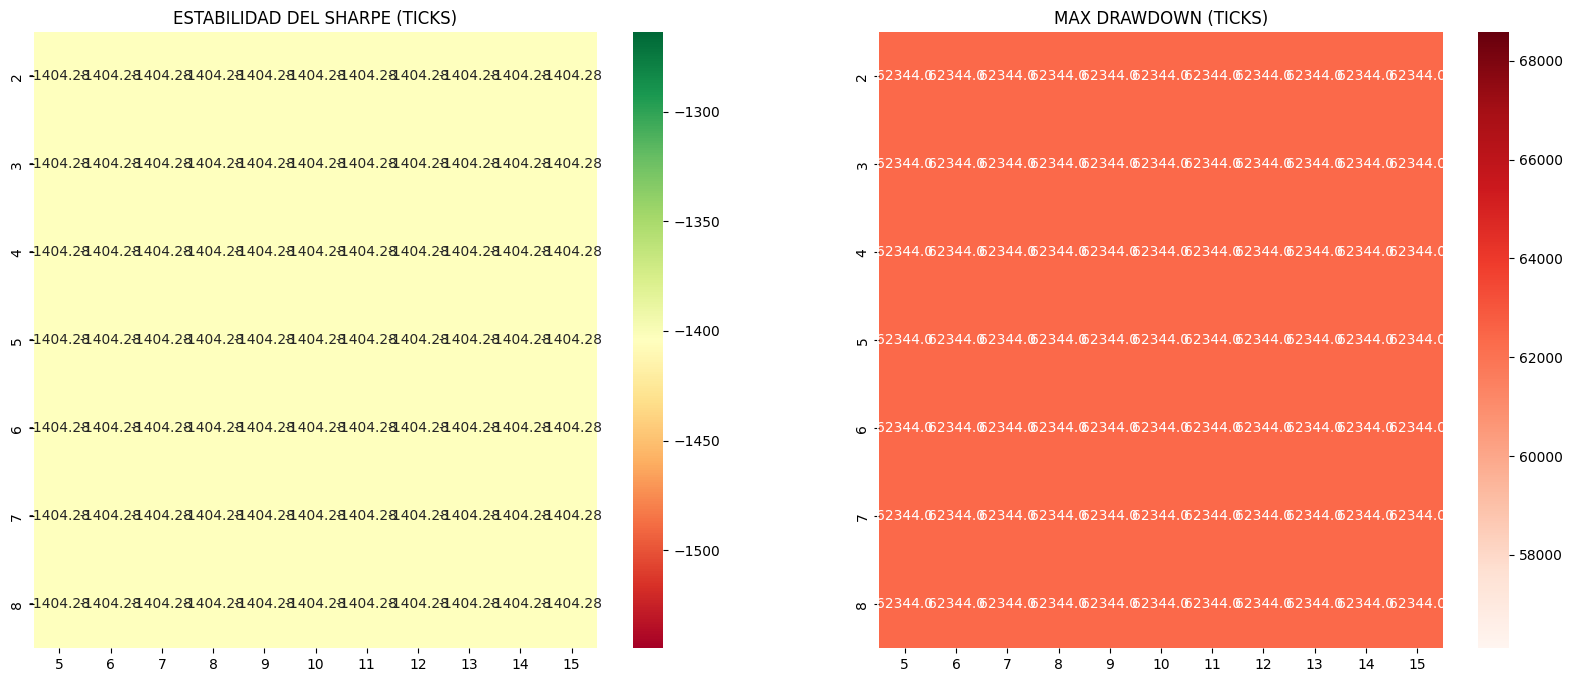

In [46]:
run_full_strategy_scan(result_torch_filtered, tps, sls)

In [47]:
def calculate_max_drawdown(pnl_array):
    """Calcula el máximo drawdown de una serie de PnL."""
    if len(pnl_array) == 0: return 0
    cumulative_pnl = np.cumsum(pnl_array)
    # Calculamos el pico máximo acumulado hasta cada punto
    peak = np.maximum.accumulate(cumulative_pnl)
    # El drawdown es la diferencia entre el pico y el valor actual
    # Si cumulative_pnl es mayor que el pico, el drawdown es 0
    drawdown = peak - cumulative_pnl
    return np.max(drawdown)

def sensitivity_scan_drawdown(df_results, tp_range, sl_range, commission=1.0):
    df_trades = df_results[df_results['pred'] == 1]
    returns = df_trades['ret_real'].values
    
    matrix_mdd = np.zeros((len(sl_range), len(tp_range)))
    
    for i, sl in enumerate(sl_range):
        for j, tp in enumerate(tp_range):
            # Lógica de TP/SL
            pnl_vector = np.where(returns >= tp, tp, 
                         np.where(returns <= -sl, -sl, returns))
            pnl_final = pnl_vector - commission
            
            # Calculamos el MDD para esta combinación
            matrix_mdd[i, j] = calculate_max_drawdown(pnl_final)

    # Visualización
    plt.figure(figsize=(12, 9))
    sns.heatmap(matrix_mdd, annot=True, fmt=".1f", 
                xticklabels=tp_range, yticklabels=sl_range, cmap='Reds')
    plt.title('Máximo Drawdown (en Ticks) por combinación TP/SL')
    plt.xlabel('Take Profit (Ticks)')
    plt.ylabel('Stop Loss (Ticks)')
    plt.show()

# --- EJECUCIÓN ---


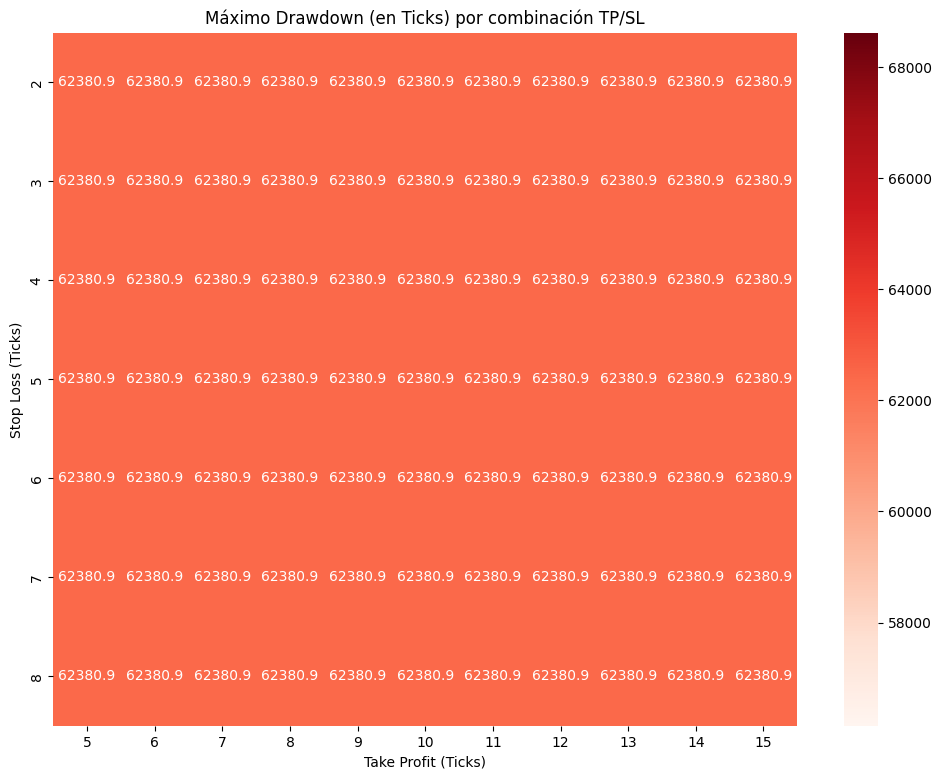

In [48]:
sensitivity_scan_drawdown(result_torch_filtered, tps, sls, commission=1.0)

In [49]:
print(f"Media de ret_ticks: {result_torch_filtered['ret_ticks'].mean()}")
print(f"Máximo de ret_ticks: {result_torch_filtered['ret_ticks'].max()}")
print(f"Mínimo de ret_ticks: {result_torch_filtered['ret_ticks'].min()}")

Media de ret_ticks: 1.2825207283023132e-05
Máximo de ret_ticks: 0.5492654790857213
Mínimo de ret_ticks: -0.5286051592192921


In [50]:
def monte_carlo_simulation(pnl_vector, iterations=1000, capital_inicial=1000):
    plt.figure(figsize=(10, 6))
    final_returns = []
    
    for _ in range(iterations):
        # Desordenamos los trades (muestreo con reemplazo)
        simulated_pnl = np.random.choice(pnl_vector, size=len(pnl_vector), replace=True)
        equity_curve = capital_inicial + np.cumsum(simulated_pnl)
        plt.plot(equity_curve, color='blue', alpha=0.01) # Curvas tenues
        final_returns.append(equity_curve[-1])
    
    plt.title(f"Simulación Monte Carlo ({iterations} caminos)")
    plt.xlabel("Número de Trades")
    plt.ylabel("Capital")
    plt.axhline(capital_inicial, color='red', linestyle='--')
    plt.show()
    
    print(f"Probabilidad de terminar en positivo: {(np.array(final_returns) > capital_inicial).mean() * 100}%")

# Uso:
# pnl_final = np.where(returns >= 8, 8, np.where(returns <= -4, -4, returns)) - 1.0
# monte_carlo_simulation(pnl_final)

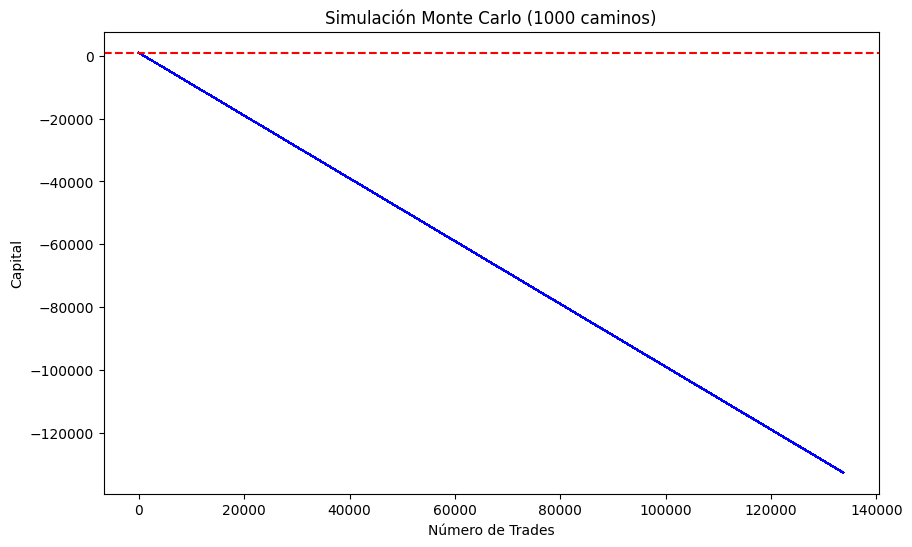

Probabilidad de terminar en positivo: 0.0%


In [51]:
pnl_final = np.where(result_torch_filtered['ret_ticks'] >= 8, 8, np.where(result_torch_filtered['ret_ticks'] <= -4, -4, result_torch_filtered['ret_ticks'])) - 1.0
monte_carlo_simulation(pnl_final)